# Análisis del Efecto del Parque Vehicular Liviano sobre PM2.5
## Ciudad Capital de Guatemala | 2022-2025
### Metodología CRISP-DM · Investigación de Maestría

---

| Parámetro | Detalle |
|---|---|
| **Hipótesis** | El crecimiento del parque vehicular liviano incide positiva y significativamente en PM2.5 |
| **Variable endógena** | PM2.5 mensual promedio (μg/m³) |
| **Variables exógenas** | Altas vehiculares mensuales, Acumulado vehicular mensual |
| **Periodo** | Marzo 2022 – Diciembre 2025 |
| **Modelos** | ARIMAX, SARIMAX |
| **Métricas** | AIC, BIC, RMSE, MAE |

---

### Índice CRISP-DM
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling — Bloque A (Correlación) + Bloque B (Series de Tiempo)
5. Evaluation
6. Deployment & Academic Insights


---
## FASE 1: BUSINESS UNDERSTANDING
---

### 1.1 Objetivo del Proyecto

Cuantificar y caracterizar estadísticamente la relación entre el crecimiento del **parque vehicular liviano** en la Ciudad Capital de Guatemala y el deterioro de la calidad del aire medido a través de la concentración de **material particulado fino PM2.5** (μg/m³), durante el período 2022-2025.

### 1.2 Preguntas de Investigación

1. ¿Existe una relación estadísticamente significativa entre el crecimiento mensual del parque vehicular y las concentraciones de PM2.5?
2. ¿Es el *flujo* de nuevas altas vehiculares (registros mensuales) o el *stock* acumulado el predictor más relevante?
3. ¿Qué tipos de vehículo (por categoría, año de fabricación o clasificación liviano/pesado) muestran mayor correlación con el PM2.5?
4. ¿Captura un modelo SARIMAX el componente estacional del PM2.5 mejor que un ARIMAX sin estacionalidad?

### 1.3 Métricas de Éxito del Modelo

| Métrica | Criterio de éxito | Interpretación |
|---|---|---|
| **AIC / BIC** | Mínimo posible | Penaliza complejidad; menor = mejor ajuste parsimónico |
| **RMSE** | < 10 μg/m³ | Error cuadrático medio; mismas unidades que PM2.5 |
| **MAE** | < 8 μg/m³ | Error absoluto medio; más robusto a outliers |
| **p-valor exógena** | < 0.05 | Significancia estadística del efecto vehicular sobre PM2.5 |
| **Ljung-Box** | p > 0.05 | Residuales sin autocorrelación (modelo bien especificado) |

### 1.4 Justificación Metodológica

Se adopta un enfoque de **series de tiempo multivariadas** (ARIMAX/SARIMAX) por las siguientes razones:

- El PM2.5 exhibe **autocorrelación temporal** (los valores de hoy dependen de los de ayer), invalidando métodos de regresión estándar OLS.
- Los datos vehiculares son de **periodicidad mensual**, mientras que el PM2.5 es diario → requiere alineación temporal.
- Se espera **estacionalidad anual** (s=12 meses) en el PM2.5 asociada a patrones meteorológicos (época seca/lluviosa en Guatemala).
- El análisis de correlación segmentado (Bloque A) provee evidencia descriptiva complementaria antes del modelado inferencial.


---
## FASE 2: DATA UNDERSTANDING
---

### 2.0 Instalación de Dependencias

Ejecutar la siguiente celda **una sola vez** si alguna librería no está instalada.


In [151]:
# Descomenta y ejecuta si necesitas instalar dependencias
# !pip install pandas numpy matplotlib seaborn statsmodels scikit-learn scipy pmdarima
print('Celda de instalación lista. Descomenta las líneas si es necesario.')


Celda de instalación lista. Descomenta las líneas si es necesario.


### 2.1 Importación de Librerías y Configuración


In [152]:
import os
import warnings
import itertools
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Series de tiempo
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Métricas de error
from sklearn.metrics import mean_squared_error, mean_absolute_error

# IPython display (disponible en Jupyter)
try:
    from IPython.display import display
except ImportError:
    display = lambda x: print(x.to_string() if hasattr(x, 'to_string') else str(x))

# pmdarima (opcional, para auto_arima)
try:
    from pmdarima import auto_arima
    PMDARIMA_OK = True
    print('pmdarima disponible — se usará auto_arima')
except ImportError:
    PMDARIMA_OK = False
    print('pmdarima no disponible — se usará búsqueda de cuadrícula (grid search) con statsmodels')

# ── Configuración visual ──────────────────────────────────────────────────────
sns.set_style('whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

# ── Directorios ───────────────────────────────────────────────────────────────
os.makedirs('./Figuras', exist_ok=True)

# ── Constantes globales ───────────────────────────────────────────────────────
RANDOM_STATE   = 42
ALPHA          = 0.05          # nivel de significancia
OMS_LIMITE     = 15.0          # μg/m³ guía OMS 2021
NCA_LIMITE     = 25.0          # μg/m³ límite NCA Guatemala
PERIODO_CORR   = '2024-12'    # fin del periodo de correlación segmentada
ESTACIONALIDAD = 12            # meses (ciclo anual)

print('Setup completado correctamente.')


pmdarima disponible — se usará auto_arima
Setup completado correctamente.


### 2.2 Carga de Datos


In [153]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
PATH_PM25 = './Data/PM25/PM25_DAIRY_FULL_2022_2025.csv'
PATH_VEH  = './Data/Vehiculos/PARQUE-VEHICULAR-2007-2025-FULL.csv'

# ── PM2.5 (diario) ────────────────────────────────────────────────────────────
df_pm25_raw = pd.read_csv(PATH_PM25)
print('=== PM2.5 Dataset ===')
print(f'  Shape     : {df_pm25_raw.shape}')
print(f'  Columnas  : {df_pm25_raw.columns.tolist()}')
yr_min = int(df_pm25_raw['YEAR'].min())
mo_min = int(df_pm25_raw['MONTH'].min())
yr_max = int(df_pm25_raw['YEAR'].max())
mo_max = int(df_pm25_raw['MONTH'].max())
print(f'  Rango     : {yr_min}/{mo_min:02d} – {yr_max}/{mo_max:02d}')
display(df_pm25_raw.head(5))

# ── Parque Vehicular (mensual) ────────────────────────────────────────────────
# dtype={'MES': str} para preservar ceros a la izquierda si existen
df_veh_raw = pd.read_csv(PATH_VEH, dtype={'MES': str}, low_memory=False)
print('\n=== Vehicular Dataset ===')
print(f'  Shape     : {df_veh_raw.shape}')
print(f'  Columnas  : {df_veh_raw.columns.tolist()}')
anios = sorted(df_veh_raw['ANIO_ALZA'].dropna().astype(int).unique())
print(f'  Años      : {anios[:5]} ... {anios[-5:]}')
tipos = df_veh_raw['TIPO_VEHICULO'].dropna().nunique()
print(f'  Tipos únicos de vehículo: {tipos}')
display(df_veh_raw.head(5))


=== PM2.5 Dataset ===
  Shape     : (1380, 4)
  Columnas  : ['YEAR', 'MONTH', 'DAY', 'PM25']
  Rango     : 2022/01 – 2025/12


,YEAR,MONTH,DAY,PM25
0,2022,3,4,4.6000
1,2022,3,7,42.0000
2,2022,3,8,55.0000
3,2022,3,9,24.3000
4,2022,3,10,73.7000



=== Vehicular Dataset ===
  Shape     : (557454, 8)
  Columnas  : ['ANIO_ALZA', 'MES', 'MODELO_VEHICULO', 'LINEA_VEHICULO', 'TIPO_VEHICULO', 'USO_VEHICULO', 'MARCA_VEHICULO', 'CANTIDAD']
  Años      : [np.int64(1980), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993)] ... [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Tipos únicos de vehículo: 74


,ANIO_ALZA,MES,MODELO_VEHICULO,LINEA_VEHICULO,TIPO_VEHICULO,USO_VEHICULO,MARCA_VEHICULO,CANTIDAD
0,2007,05,2003,SANTA FE V6 4X2,CAMIONETA,PARTICULAR,HYUNDAI,1
1,2007,05,2001,SWIFT,AUTOMOVIL,PARTICULAR,SUZUKI,1
2,2007,05,1995,METRO LSI,AUTOMOVIL,PARTICULAR,GEO,1
3,2007,05,2003,JETTA,AUTOMOVIL,PARTICULAR,VOLKSWAGEN,1
4,2007,05,2007,5,CAMIONETA,PARTICULAR,MAZDA,5


### 2.3 EDA Preliminar

Se inspeccionan dimensiones, tipos de datos, valores nulos y estadísticas descriptivas de cada dataset antes de cualquier transformación.


In [154]:
def eda_report(df, name):
    """
    Reporte EDA estándar: tipos, nulos y estadísticas descriptivas.
    """
    sep = '─' * 60
    print(f'\n{sep}')
    print(f'  EDA: {name}')
    print(f'{sep}')
    print(f'  Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas')

    # Tipos de datos
    print('\n  Tipos de datos:')
    for col, dtype in df.dtypes.items():
        print(f'    {col:<25} {dtype}')

    # Valores nulos
    nulls = df.isnull().sum()
    pct   = (nulls / len(df) * 100).round(2)
    null_df = pd.concat([nulls, pct], axis=1, keys=['Nulos', '%'])
    null_df = null_df[null_df['Nulos'] > 0]
    if len(null_df) == 0:
        print('\n  Valores nulos: ninguno encontrado.')
    else:
        print('\n  Valores nulos:')
        display(null_df)

    # Estadísticas descriptivas numéricas
    print('\n  Estadísticas descriptivas (numéricas):')
    display(df.describe())


eda_report(df_pm25_raw,  'PM2.5 Diario (2022-2025)')
eda_report(df_veh_raw,   'Parque Vehicular (2007-2025)')



────────────────────────────────────────────────────────────
  EDA: PM2.5 Diario (2022-2025)
────────────────────────────────────────────────────────────
  Dimensiones : 1,380 filas × 4 columnas

  Tipos de datos:
    YEAR                      int64
    MONTH                     int64
    DAY                       int64
    PM25                      float64

  Valores nulos: ninguno encontrado.

  Estadísticas descriptivas (numéricas):


,YEAR,MONTH,DAY,PM25
count,1380.0000,1380.0000,1380.0000,1380.0000
mean,2023.5790,6.7884,15.7920,30.4328
std,1.0940,3.3516,8.8263,42.2411
min,2022.0000,1.0000,1.0000,0.8000
25%,2023.0000,4.0000,8.0000,9.1000
50%,2024.0000,7.0000,16.0000,18.1500
75%,2025.0000,10.0000,23.0000,37.1250
max,2025.0000,12.0000,31.0000,1016.0000



────────────────────────────────────────────────────────────
  EDA: Parque Vehicular (2007-2025)
────────────────────────────────────────────────────────────
  Dimensiones : 557,454 filas × 8 columnas

  Tipos de datos:
    ANIO_ALZA                 int64
    MES                       str
    MODELO_VEHICULO           str
    LINEA_VEHICULO            str
    TIPO_VEHICULO             str
    USO_VEHICULO              str
    MARCA_VEHICULO            str
    CANTIDAD                  int64

  Valores nulos:


,Nulos,%
LINEA_VEHICULO,20,0.0000



  Estadísticas descriptivas (numéricas):


,ANIO_ALZA,CANTIDAD
count,557454.0000,557454.0000
mean,2012.5458,2.7514
std,9.7378,14.3432
min,1980.0000,1.0000
25%,2006.0000,1.0000
50%,2015.0000,1.0000
75%,2021.0000,2.0000
max,2025.0000,1889.0000


### 2.4 Visualización Inicial de las Series Crudas

Se grafica el PM2.5 diario y las altas vehiculares anuales en su estado **sin procesar** para identificar patrones, estacionalidad y outliers visuales.


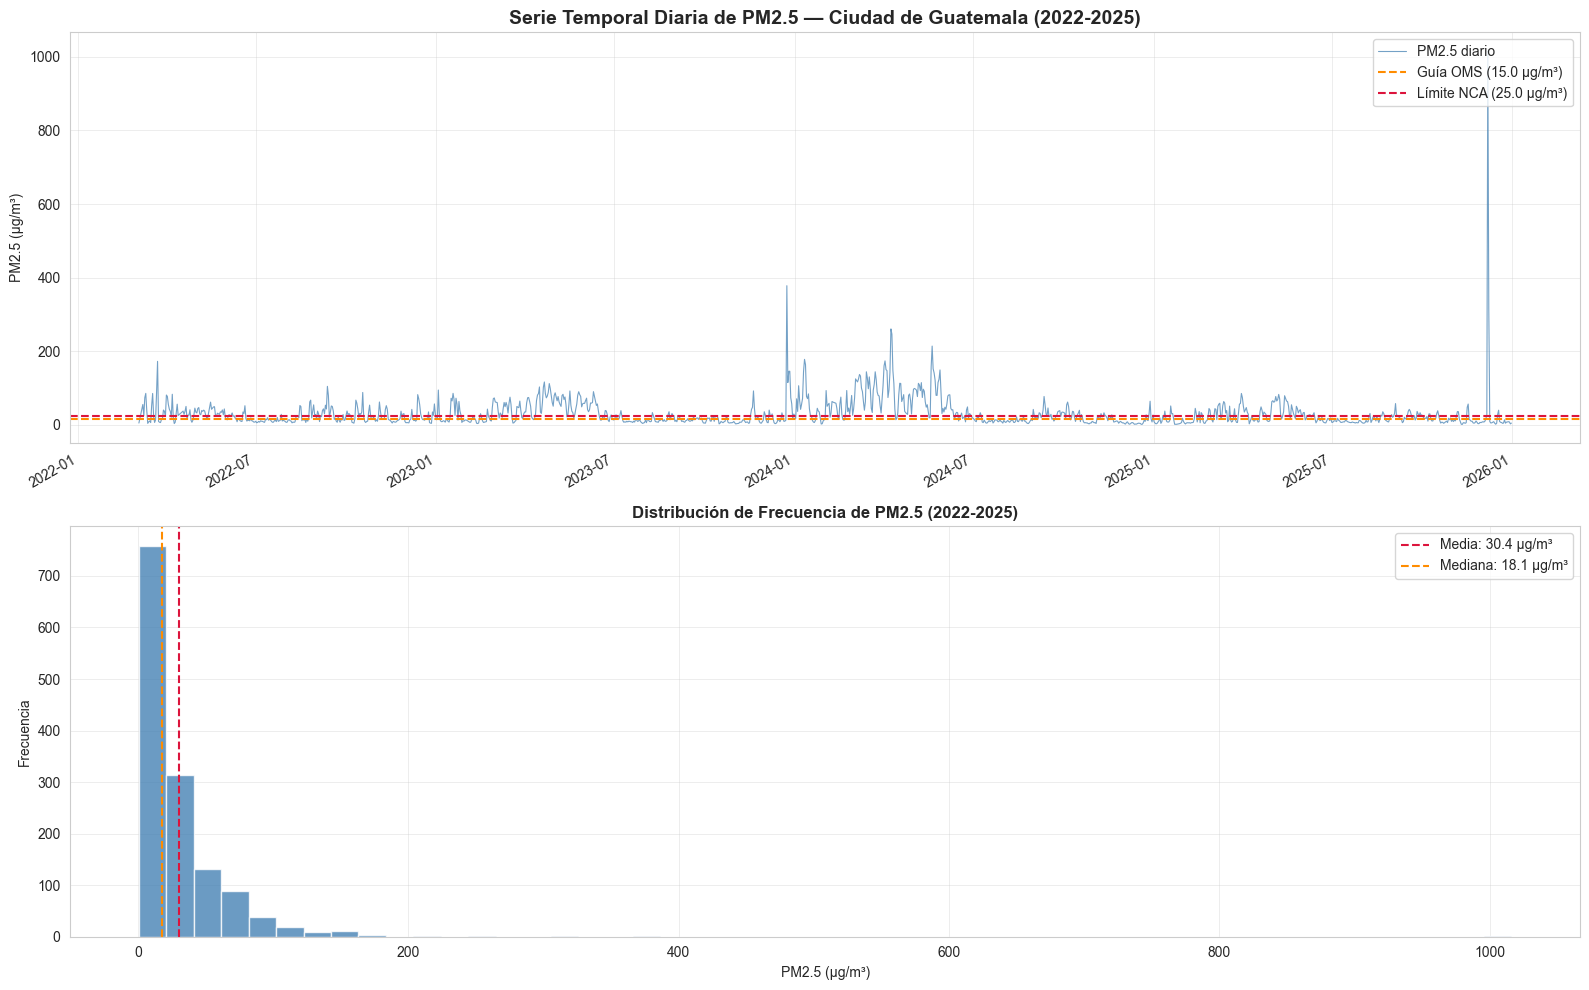

Registros con PM2.5 > NCA (25.0): 538 (39.0%)


In [155]:
# ── Construir columna FECHA en el dataset de PM2.5 ────────────────────────────
df_pm25_raw['FECHA'] = pd.to_datetime(
    df_pm25_raw[['YEAR', 'MONTH', 'DAY']]
    .rename(columns={'YEAR': 'year', 'MONTH': 'month', 'DAY': 'day'})
)
df_pm25_raw = df_pm25_raw.sort_values('FECHA').reset_index(drop=True)

# ── Figura 1: Serie diaria PM2.5 + distribución ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel superior: serie temporal
ax = axes[0]
ax.plot(df_pm25_raw['FECHA'], df_pm25_raw['PM25'],
        color='steelblue', alpha=0.75, linewidth=0.8, label='PM2.5 diario')
ax.axhline(OMS_LIMITE, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'Guía OMS ({OMS_LIMITE} μg/m³)')
ax.axhline(NCA_LIMITE, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Límite NCA ({NCA_LIMITE} μg/m³)')
ax.set_title('Serie Temporal Diaria de PM2.5 — Ciudad de Guatemala (2022-2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel inferior: histograma
ax2 = axes[1]
pm25_values = df_pm25_raw['PM25'].dropna()
ax2.hist(pm25_values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(pm25_values.mean(), color='crimson', linestyle='--',
            label=f'Media: {pm25_values.mean():.1f} μg/m³')
ax2.axvline(pm25_values.median(), color='darkorange', linestyle='--',
            label=f'Mediana: {pm25_values.median():.1f} μg/m³')
ax2.set_title('Distribución de Frecuencia de PM2.5 (2022-2025)', fontsize=12, fontweight='bold')
ax2.set_xlabel('PM2.5 (μg/m³)')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.tight_layout()
plt.savefig('./Figuras/fig01_pm25_serie_cruda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Registros con PM2.5 > NCA ({NCA_LIMITE}): {(pm25_values > NCA_LIMITE).sum()} ({(pm25_values > NCA_LIMITE).mean()*100:.1f}%)')


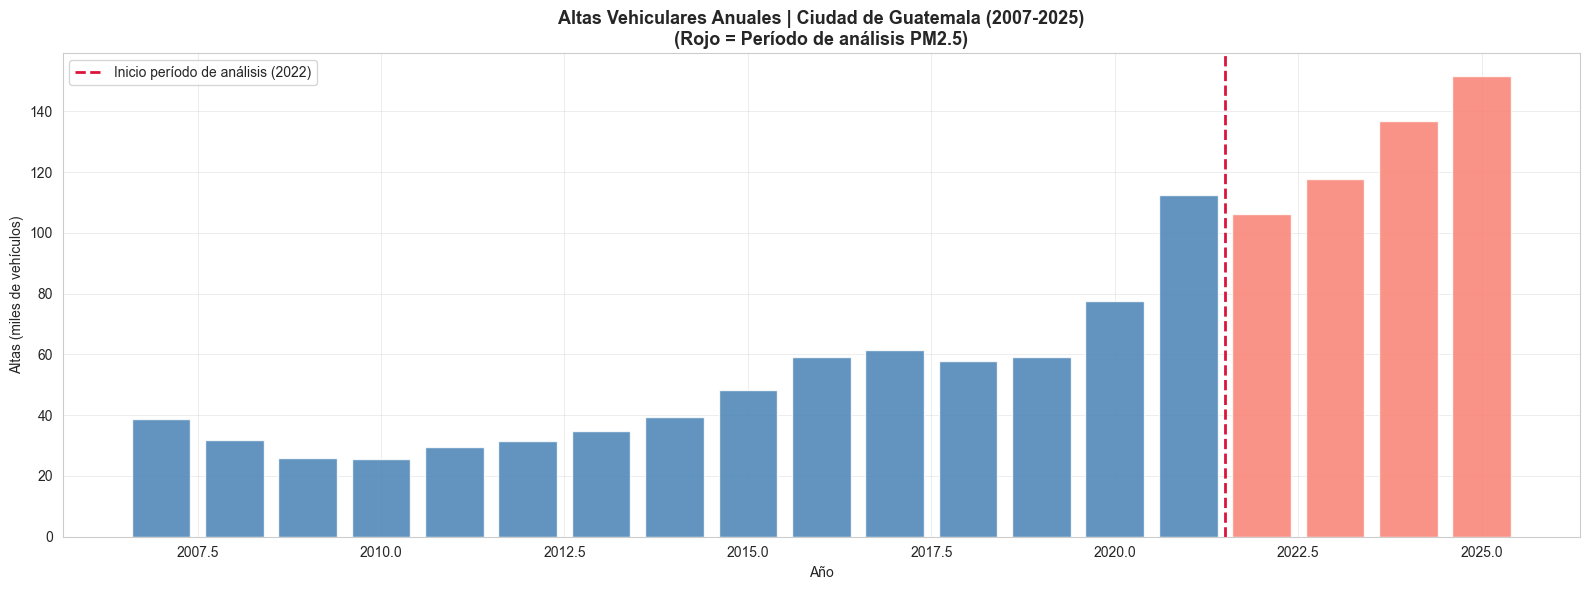

In [156]:
# ── Figura 2: Altas vehiculares anuales (serie cruda) ─────────────────────────
df_veh_anio = df_veh_raw.copy()
df_veh_anio['ANIO_ALZA'] = pd.to_numeric(df_veh_anio['ANIO_ALZA'], errors='coerce')
df_veh_anio['CANTIDAD']  = pd.to_numeric(df_veh_anio['CANTIDAD'],  errors='coerce')

altas_anuales = (df_veh_anio.groupby('ANIO_ALZA')['CANTIDAD']
                             .sum()
                             .reset_index()
                             .dropna())
altas_anuales.columns = ['ANIO', 'ALTAS']
altas_anuales = altas_anuales[altas_anuales['ANIO'] >= 2007]

colors = ['salmon' if a >= 2022 else 'steelblue' for a in altas_anuales['ANIO']]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(altas_anuales['ANIO'], altas_anuales['ALTAS'] / 1_000,
       color=colors, edgecolor='white', alpha=0.85)
ax.axvline(x=2021.5, color='crimson', linestyle='--', linewidth=2,
           label='Inicio período de análisis (2022)')
ax.set_title('Altas Vehiculares Anuales | Ciudad de Guatemala (2007-2025)\n'
             '(Rojo = Período de análisis PM2.5)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Altas (miles de vehículos)')
ax.legend()

plt.tight_layout()
plt.savefig('./Figuras/fig02_altas_vehiculares_anuales.png', dpi=150, bbox_inches='tight')
plt.show()


---
## FASE 3: DATA PREPARATION
---

Esta fase es crítica y comprende:
1. Filtrado temporal al período 2022-2025
2. Clasificación LIVIANO / PESADO por tipo de vehículo
3. Ingeniería de características: ALTAS (flujo) y ACUMULADO (stock)
4. Agregación mensual del PM2.5 (de diario a mensual)
5. Construcción del DataFrame Maestro alineado temporalmente
6. Pruebas de estacionariedad ADF y diferenciación

### 3.1 Filtrado Temporal y Tipado


In [157]:
# ── Copia limpia del dataset vehicular ────────────────────────────────────────
df_veh = df_veh_raw.copy()
df_veh['ANIO_ALZA'] = pd.to_numeric(df_veh['ANIO_ALZA'], errors='coerce')
df_veh['MES']       = pd.to_numeric(df_veh['MES'],       errors='coerce').astype('Int64')
df_veh['CANTIDAD']  = pd.to_numeric(df_veh['CANTIDAD'],  errors='coerce')
df_veh['MODELO_VEHICULO'] = pd.to_numeric(df_veh['MODELO_VEHICULO'], errors='coerce').astype('Int64')

# Eliminar filas sin clave temporal o cantidad
df_veh.dropna(subset=['ANIO_ALZA', 'MES', 'CANTIDAD'], inplace=True)

# ── Filtrar a 2022-2025 ───────────────────────────────────────────────────────
df_veh_f = df_veh[df_veh['ANIO_ALZA'].between(2022, 2025)].copy()

print(f'Registros vehiculares 2022-2025 : {len(df_veh_f):,}')
print(f'Años presentes                  : {sorted(df_veh_f["ANIO_ALZA"].unique())}')
print(f'Meses presentes                 : {sorted(df_veh_f["MES"].unique())}')
print(f'CANTIDAD total                  : {df_veh_f["CANTIDAD"].sum():,.0f} altas vehiculares')


Registros vehiculares 2022-2025 : 118,806
Años presentes                  : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Meses presentes                 : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
CANTIDAD total                  : 512,565 altas vehiculares


### 3.2 Clasificación LIVIANO / PESADO

Se crea la columna `LIVIANO_PESADO` aplicando el mapeo oficial de tipos de vehículo definido por el análisis.


In [158]:
LIVIANOS = {
    'AUTOMOVIL', 'AMBULANCIA', 'JEEP', 'PICK UP', 'CARRO PARA GOLF',
    'CAMIONETA', 'CAMIONETA AGRICOLA', 'CAMIONETA SPORT', 'CAMIONETILLA',
    'PANEL', 'MICROBUS', 'MICROBUS ESCOLAR', 'MOTO', 'SCOOTER', 'TRIMOTO',
    'CUATRIMOTO', 'LIMOSINA', 'CARRO FUNEBRE', 'VEHICULO RUSTICO', 'GO-KART'
}

PESADOS = {
    'AUTOBUS', 'AUTOBUS ESCOLARP', 'BARREDORA INDUST', 'BUS', 'BUS ESCOLAR',
    'CABEZAL', 'CAMION', 'CAMION BOMBEROS', 'CAMION CHASIS', 'CAMION CISTERNA',
    'CAMION FRIGORIFICO', 'CAMION FURGON', 'CAMION GRUA', 'CAMION MEZCLADOR',
    'CAMION PERFORADOR', 'CAMION VOLTEO', 'CISTERNA', 'ESPARCIDORA', 'FURGON',
    'GONDOLA', 'GRANELERA', 'GRUA', 'GRUA HIDRAULICA', 'JAULA CANERA',
    'LOW BOY', 'MEZCLADORA', 'MINIBUS', 'OMNIBUS', 'PERFORADORA', 'PLATAFORMA',
    'PORTA CONTENEDOR', 'RASTRA', 'REMOLQUE', 'RETROEXCAVADORA', 'SEMI REMOLQUE',
    'TACUASINA', 'TANQUE', 'TOLBA', 'TRACTO CAMION', 'TRACTOR', 'TRACTOR AGRICOLA',
    'TRACTOR CONSTRUC', 'TRANS DE CARGA', 'VOLQUETA', 'PALANGANA', 'ARA A',
    'CARRETA-CARRETON', 'CAMIONETA ESCOLA', 'MINI TRACTOR', 'MINITRACTOR',
    'CASA RODANTE', 'MONTA CARGA', 'CARRETILLA-AUTOM', 'COCHE VIVIENDA'
}


def clasificar_lp(tipo):
    t = str(tipo).strip().upper()
    if t in LIVIANOS:
        return 'LIVIANO'
    elif t in PESADOS:
        return 'PESADO'
    return 'OTRO'


df_veh_f['LIVIANO_PESADO'] = df_veh_f['TIPO_VEHICULO'].apply(clasificar_lp)

# Reporte de clasificación
resumen_lp = (df_veh_f.groupby('LIVIANO_PESADO')['CANTIDAD']
                       .agg(['sum', 'count'])
                       .rename(columns={'sum': 'CANTIDAD_TOTAL', 'count': 'FILAS'})
                       .sort_values('CANTIDAD_TOTAL', ascending=False))
resumen_lp['%'] = (resumen_lp['CANTIDAD_TOTAL'] / resumen_lp['CANTIDAD_TOTAL'].sum() * 100).round(2)
print('Distribución LIVIANO / PESADO (suma de CANTIDAD):')
display(resumen_lp)

sin_clase = df_veh_f[df_veh_f['LIVIANO_PESADO'] == 'OTRO']['TIPO_VEHICULO'].unique()
if len(sin_clase) > 0:
    print(f'\nTipos sin clasificar ({len(sin_clase)}): {list(sin_clase)}')


Distribución LIVIANO / PESADO (suma de CANTIDAD):


,CANTIDAD_TOTAL,FILAS,%
LIVIANO_PESADO,,,
LIVIANO,487593,106840,95.1300
PESADO,24972,11966,4.8700


### 3.3 Ingeniería de Características — ALTAS y ACUMULADO

- **ALTAS**: Suma mensual de `CANTIDAD` agrupada por año y mes → refleja el **flujo** de vehículos que ingresan al parque.
- **ACUMULADO**: `cumsum()` de las altas mensuales → proxy del **stock total** en circulación mes a mes (base 2022).


In [159]:
def construir_serie_vehicular(df, extra_cols=None):
    """
    Calcula altas mensuales y acumulado, opcionalmente segmentado.

    Parámetros
    ----------
    df         : DataFrame con ANIO_ALZA, MES, CANTIDAD
    extra_cols : lista de columnas adicionales para la segmentación (None = total)

    Retorna
    -------
    DataFrame indexado por PERIODO (Period mensual)
    """
    group_keys = ['ANIO_ALZA', 'MES'] + (extra_cols or [])
    altas = (df.groupby(group_keys)['CANTIDAD']
               .sum()
               .reset_index()
               .rename(columns={'CANTIDAD': 'ALTAS'}))

    # Crear columna de período
    altas['PERIODO'] = pd.to_datetime(
        altas['ANIO_ALZA'].astype(int).astype(str) + '-' +
        altas['MES'].astype(int).astype(str).str.zfill(2),
        format='%Y-%m'
    ).dt.to_period('M')

    altas = altas.sort_values('PERIODO')

    if extra_cols is None:
        altas = altas.set_index('PERIODO')
        altas['ACUMULADO'] = altas['ALTAS'].cumsum()
        altas.drop(columns=['ANIO_ALZA', 'MES'], inplace=True)

    return altas


# Serie total (2022-2025)
df_veh_ts = construir_serie_vehicular(df_veh_f)

print('Serie vehicular mensual — primeras filas:')
display(df_veh_ts.head(10))

print(f'\nTotal altas 2022-2025  : {df_veh_ts["ALTAS"].sum():,.0f}')
print(f'Acumulado final        : {df_veh_ts["ACUMULADO"].iloc[-1]:,.0f}')
print(f'Períodos disponibles   : {len(df_veh_ts)}')


Serie vehicular mensual — primeras filas:


,ALTAS,ACUMULADO
PERIODO,,
2022-01,9208,9208
2022-02,8825,18033
2022-03,9418,27451
2022-04,9124,36575
2022-05,9811,46386
2022-06,11113,57499
2022-07,9099,66598
2022-08,9336,75934
2022-09,8252,84186



Total altas 2022-2025  : 512,565
Acumulado final        : 512,565
Períodos disponibles   : 48


### 3.4 Agregación Mensual de PM2.5 y DataFrame Maestro


In [160]:
# ── Agregar PM2.5 de diario a mensual ─────────────────────────────────────────
df_pm25 = df_pm25_raw.copy()
df_pm25['PERIODO'] = df_pm25['FECHA'].dt.to_period('M')

df_pm25_m = (df_pm25.groupby('PERIODO')['PM25']
                     .agg(
                         PM25_MEAN   = 'mean',
                         PM25_MEDIAN = 'median',
                         PM25_P95    = lambda x: x.quantile(0.95),
                         PM25_N      = 'count'
                     ))

print(f'PM2.5 mensual | rango: {df_pm25_m.index.min()} – {df_pm25_m.index.max()}')
print(f'Total meses            : {len(df_pm25_m)}')
display(df_pm25_m.head())

# ── DataFrame Maestro (inner join por período) ────────────────────────────────
df_master = df_pm25_m.join(df_veh_ts, how='inner')
df_master.dropna(subset=['PM25_MEAN', 'ALTAS', 'ACUMULADO'], inplace=True)
df_master.sort_index(inplace=True)

print(f'\nDataFrame Maestro:')
print(f'  Meses alineados : {len(df_master)}')
print(f'  Rango           : {df_master.index.min()} – {df_master.index.max()}')
print(f'  Columnas        : {df_master.columns.tolist()}')
display(df_master.head(10))


PM2.5 mensual | rango: 2022-03 – 2025-12
Total meses            : 46


,PM25_MEAN,PM25_MEDIAN,PM25_P95,PM25_N
PERIODO,,,,
2022-03,36.2192,22.5000,87.3000,26
2022-04,34.6538,30.1500,79.7500,26
2022-05,35.0429,34.7000,48.7900,28
2022-06,18.1700,16.0000,33.4750,30
2022-07,11.1000,10.1000,19.4500,31



DataFrame Maestro:
  Meses alineados : 46
  Rango           : 2022-03 – 2025-12
  Columnas        : ['PM25_MEAN', 'PM25_MEDIAN', 'PM25_P95', 'PM25_N', 'ALTAS', 'ACUMULADO']


,PM25_MEAN,PM25_MEDIAN,PM25_P95,PM25_N,ALTAS,ACUMULADO
PERIODO,,,,,,
2022-03,36.2192,22.5000,87.3000,26,9418,27451
2022-04,34.6538,30.1500,79.7500,26,9124,36575
2022-05,35.0429,34.7000,48.7900,28,9811,46386
2022-06,18.1700,16.0000,33.4750,30,11113,57499
2022-07,11.1000,10.1000,19.4500,31,9099,66598
2022-08,21.2333,15.6500,58.3450,30,9336,75934
2022-09,29.6500,23.3000,67.9500,30,8252,84186
2022-10,26.2871,23.9000,62.7000,31,6817,91003
2022-11,20.2233,15.0500,47.4350,30,7552,98555


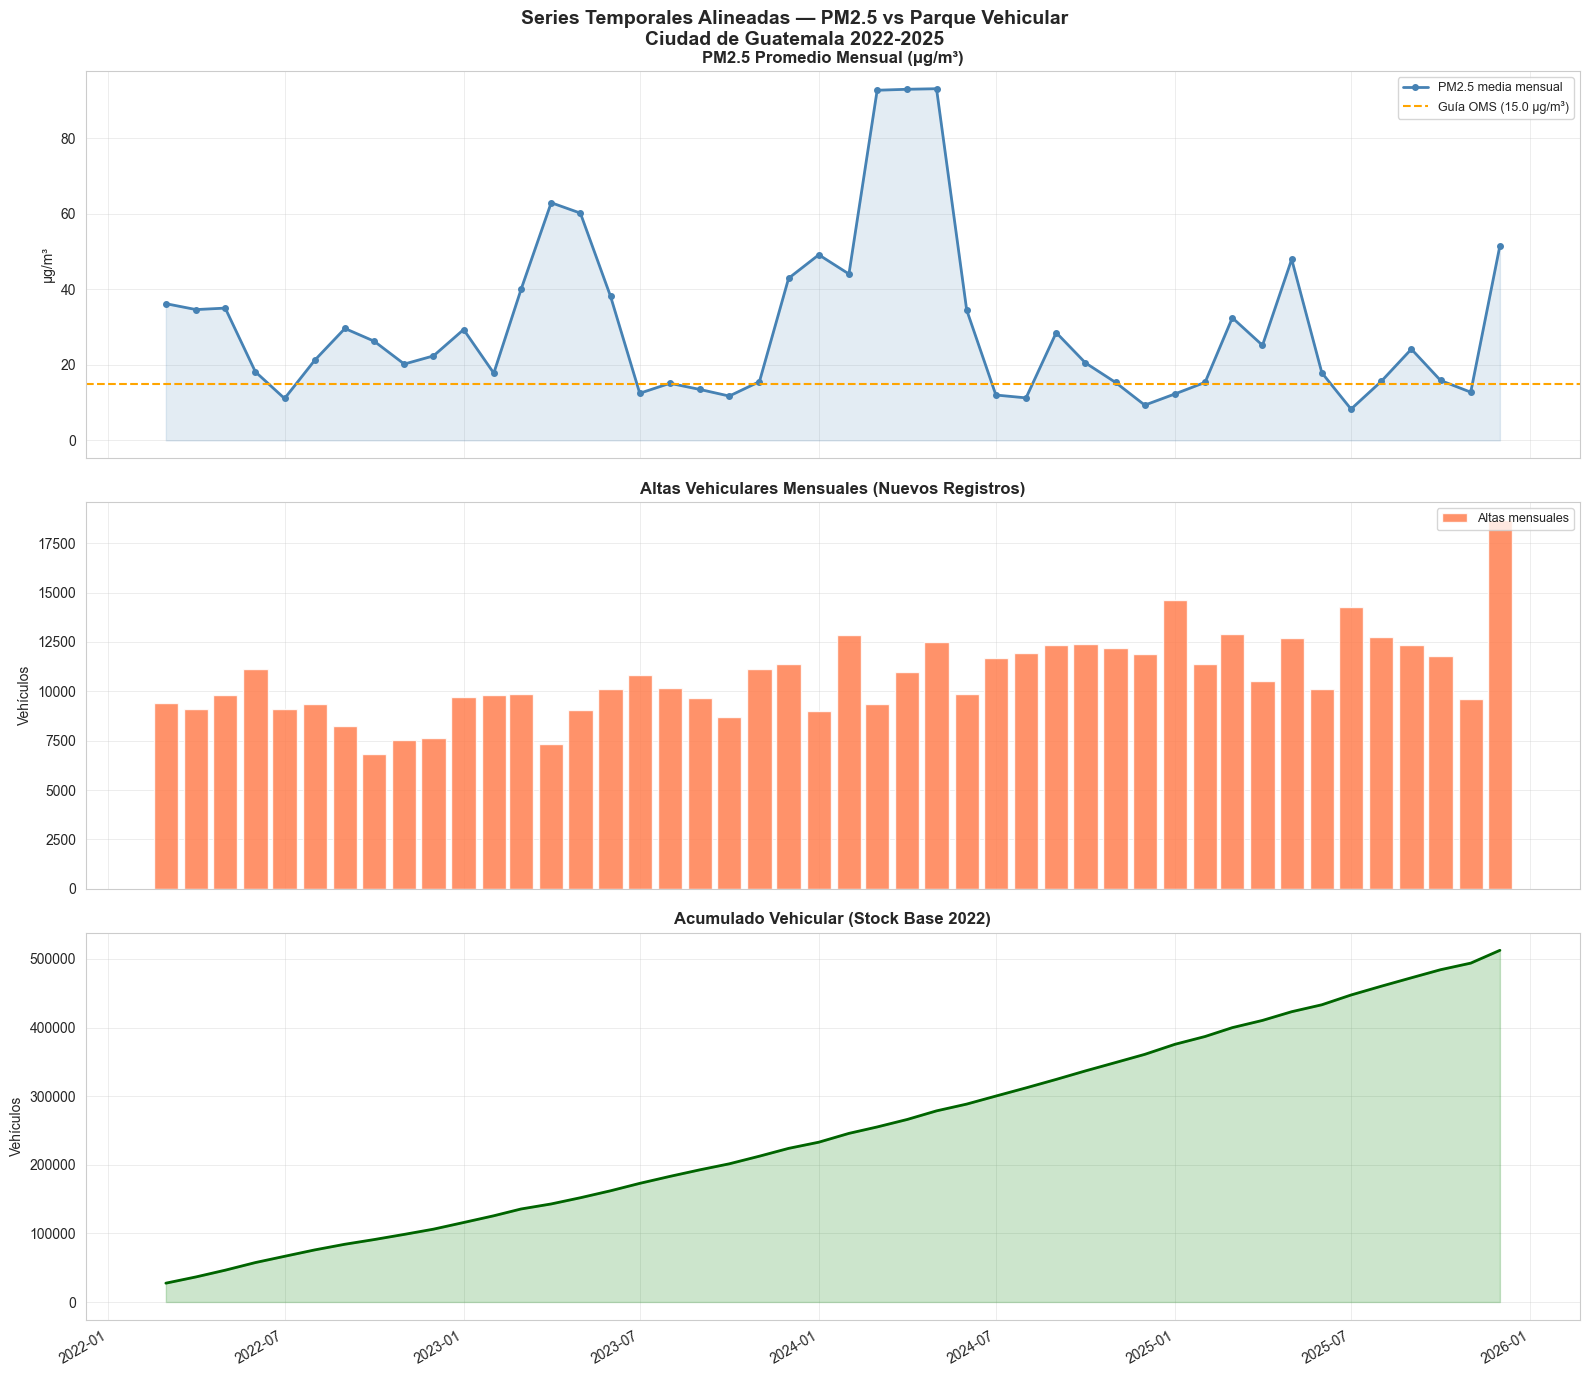

In [161]:
# ── Figura 3: Series alineadas ────────────────────────────────────────────────
idx_dt = df_master.index.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# Panel 1: PM2.5 mensual
axes[0].plot(idx_dt, df_master['PM25_MEAN'], color='steelblue',
             linewidth=2, marker='o', markersize=4, label='PM2.5 media mensual')
axes[0].fill_between(idx_dt, df_master['PM25_MEAN'], alpha=0.15, color='steelblue')
axes[0].axhline(OMS_LIMITE, color='orange', linestyle='--', lw=1.5,
                label=f'Guía OMS ({OMS_LIMITE} μg/m³)')
axes[0].set_title('PM2.5 Promedio Mensual (μg/m³)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('μg/m³')
axes[0].legend(loc='upper right', fontsize=9)

# Panel 2: Altas vehiculares
axes[1].bar(idx_dt, df_master['ALTAS'], width=25, color='coral', alpha=0.85,
            label='Altas mensuales')
axes[1].set_title('Altas Vehiculares Mensuales (Nuevos Registros)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Vehículos')
axes[1].legend(loc='upper right', fontsize=9)

# Panel 3: Acumulado
axes[2].plot(idx_dt, df_master['ACUMULADO'], color='darkgreen', linewidth=2)
axes[2].fill_between(idx_dt, df_master['ACUMULADO'], alpha=0.2, color='green')
axes[2].set_title('Acumulado Vehicular (Stock Base 2022)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Vehículos')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Series Temporales Alineadas — PM2.5 vs Parque Vehicular\nCiudad de Guatemala 2022-2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./Figuras/fig03_series_alineadas.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Pruebas de Estacionariedad — Augmented Dickey-Fuller (ADF)

**Hipótesis:**
- H₀: La serie posee raíz unitaria → **NO es estacionaria**
- H₁: La serie **es estacionaria**

Decisión: si `p-valor < α = 0.05` → rechazamos H₀ → la serie es estacionaria.

Los modelos ARIMA requieren series estacionarias; si las series no lo son, se aplica diferenciación (`d≥1` o `D≥1` para la parte estacional).


In [162]:
def adf_test(series, nombre, alpha=0.05):
    """
    Ejecuta la prueba ADF y devuelve un dict con los resultados.
    """
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC')

    adf_stat   = result[0]
    p_valor    = result[1]
    n_lags     = result[2]
    n_obs      = result[3]
    criticos   = result[4]
    estac      = p_valor < alpha

    sep = '─' * 55
    print(f'\n{sep}')
    print(f'  ADF Test: {nombre}')
    print(f'{sep}')
    print(f'  Estadístico ADF  : {adf_stat:.4f}')
    print(f'  p-valor          : {p_valor:.6f}')
    print(f'  Rezagos (AIC)    : {n_lags}')
    print(f'  Observaciones    : {n_obs}')
    for k, v in criticos.items():
        print(f'  Valor crítico {k:>4}: {v:.4f}')
    estado = 'ESTACIONARIA' if estac else 'NO ESTACIONARIA'
    print(f'\n  => Serie {estado} (p={p_valor:.4f} {"<" if estac else ">="} α={alpha})')

    return {
        'serie': nombre, 'ADF': adf_stat, 'p_valor': p_valor,
        'lags': n_lags, 'estacionaria': estac
    }


# Probar las tres series del DataFrame Maestro
resultados_adf = []
for col, nombre in [
    ('PM25_MEAN',  'PM2.5 Media Mensual'),
    ('ALTAS',      'Altas Vehiculares Totales'),
    ('ACUMULADO',  'Acumulado Vehicular Total')
]:
    r = adf_test(df_master[col], nombre)
    resultados_adf.append(r)

df_adf_resumen = pd.DataFrame(resultados_adf)
print('\n=== RESUMEN ADF ===')
display(df_adf_resumen)



───────────────────────────────────────────────────────
  ADF Test: PM2.5 Media Mensual
───────────────────────────────────────────────────────
  Estadístico ADF  : -3.4743
  p-valor          : 0.008672
  Rezagos (AIC)    : 1
  Observaciones    : 44
  Valor crítico   1%: -3.5886
  Valor crítico   5%: -2.9299
  Valor crítico  10%: -2.6032

  => Serie ESTACIONARIA (p=0.0087 < α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Altas Vehiculares Totales
───────────────────────────────────────────────────────
  Estadístico ADF  : -0.0787
  p-valor          : 0.951515
  Rezagos (AIC)    : 5
  Observaciones    : 40
  Valor crítico   1%: -3.6056
  Valor crítico   5%: -2.9371
  Valor crítico  10%: -2.6070

  => Serie NO ESTACIONARIA (p=0.9515 >= α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Acumulado Vehicular Total
───────────────────────────────────────────────────────
  Estadístico ADF  : 5.2833
  p-valor          : 1.000000
  Rezagos

,serie,ADF,p_valor,lags,estacionaria
0,PM2.5 Media Mensual,-3.4743,0.0087,1,True
1,Altas Vehiculares Totales,-0.0787,0.9515,5,False
2,Acumulado Vehicular Total,5.2833,1.0000,1,False


In [163]:
# ── Primera diferencia para las series no estacionarias ───────────────────────
df_master['PM25_MEAN_d1']  = df_master['PM25_MEAN'].diff()
df_master['ALTAS_d1']      = df_master['ALTAS'].diff()
df_master['ACUMULADO_d1']  = df_master['ACUMULADO'].diff()   # == ALTAS (aproximado)

print('ADF en primeras diferencias:')
res_d1 = []
for col, nombre in [
    ('PM25_MEAN_d1',  'Δ PM2.5 (1ª diferencia)'),
    ('ALTAS_d1',      'Δ Altas (1ª diferencia)'),
    ('ACUMULADO_d1',  'Δ Acumulado (1ª diferencia)')
]:
    r = adf_test(df_master[col], nombre)
    res_d1.append(r)

df_adf_d1 = pd.DataFrame(res_d1)
print('\nResumen diferencias:')
display(df_adf_d1[['serie', 'ADF', 'p_valor', 'estacionaria']])


ADF en primeras diferencias:

───────────────────────────────────────────────────────
  ADF Test: Δ PM2.5 (1ª diferencia)
───────────────────────────────────────────────────────
  Estadístico ADF  : -5.5482
  p-valor          : 0.000002
  Rezagos (AIC)    : 0
  Observaciones    : 44
  Valor crítico   1%: -3.5886
  Valor crítico   5%: -2.9299
  Valor crítico  10%: -2.6032

  => Serie ESTACIONARIA (p=0.0000 < α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Δ Altas (1ª diferencia)
───────────────────────────────────────────────────────
  Estadístico ADF  : -4.6498
  p-valor          : 0.000104
  Rezagos (AIC)    : 4
  Observaciones    : 40
  Valor crítico   1%: -3.6056
  Valor crítico   5%: -2.9371
  Valor crítico  10%: -2.6070

  => Serie ESTACIONARIA (p=0.0001 < α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Δ Acumulado (1ª diferencia)
───────────────────────────────────────────────────────
  Estadístico ADF  : -0.1705
  p-valor

,serie,ADF,p_valor,estacionaria
0,Δ PM2.5 (1ª diferencia),-5.5482,0.0000,True
1,Δ Altas (1ª diferencia),-4.6498,0.0001,True
2,Δ Acumulado (1ª diferencia),-0.1705,0.9419,False


---
## FASE 4: MODELING
---

## Bloque A — Análisis de Correlación Avanzada y Segmentada (2022-2024)

Se calculan matrices de correlación **Pearson** (relación lineal) y **Spearman** (relación monótona, robusta a outliers) para PM2.5 mensual contra las siguientes segmentaciones del parque vehicular:

| # | Tipo de métrica | Segmentación |
|---|---|---|
| A.1 | Acumulado | Por Modelo (año de fabricación) |
| A.2 | Acumulado | Por Tipo de Vehículo |
| A.3 | Acumulado | Por Macro-categoría (LIVIANO / PESADO) |
| A.4 | Altas | Por Modelo (año de fabricación) |
| A.5 | Altas | Por Tipo de Vehículo |
| A.6 | Altas | Por Macro-categoría (LIVIANO / PESADO) |


In [164]:
# ── Función reutilizable: correlación segmentada ──────────────────────────────
def correlacion_segmentada(df_veh, df_pm25_men, segmento_col,
                            tipo='ACUMULADO', top_n=15, periodo_fin='2024-12'):
    """
    Calcula correlaciones de Pearson y Spearman entre PM2.5 y el parque
    vehicular segmentado por `segmento_col`.

    Parámetros
    ----------
    df_veh       : DataFrame vehicular (con columnas ANIO_ALZA, MES, CANTIDAD, segmento_col)
    df_pm25_men  : DataFrame PM2.5 mensual con columna PM25_MEAN (índice tipo Period)
    segmento_col : str — columna de segmentación
    tipo         : 'ACUMULADO' o 'ALTAS'
    top_n        : N categorías de mayor volumen a retener
    periodo_fin  : str — 'YYYY-MM' hasta dónde filtrar

    Retorna
    -------
    df_corr : DataFrame con correlaciones (index = categoría del segmento)
    df_join : DataFrame completo alineado (para scatter plots)
    """
    # Filtrar período y construir PERIODO
    df_v = df_veh.copy()
    df_v['PERIODO'] = pd.to_datetime(
        df_v['ANIO_ALZA'].astype(int).astype(str) + '-' +
        df_v['MES'].astype(int).astype(str).str.zfill(2),
        format='%Y-%m'
    ).dt.to_period('M')

    fin_period = pd.Period(periodo_fin, 'M')
    df_v = df_v[df_v['PERIODO'] <= fin_period]

    # Agrupar por período y segmento
    altas_seg = (df_v.groupby(['PERIODO', segmento_col])['CANTIDAD']
                      .sum()
                      .reset_index())

    # Pivot: filas = PERIODO, columnas = categorías del segmento
    pivot = altas_seg.pivot_table(
        index='PERIODO', columns=segmento_col,
        values='CANTIDAD', aggfunc='sum', fill_value=0
    ).sort_index()

    # Acumulado si se requiere
    if tipo == 'ACUMULADO':
        pivot = pivot.cumsum()

    # Top N categorías por volumen total
    top_cats = pivot.sum().nlargest(top_n).index.tolist()
    pivot = pivot[top_cats]

    # Alinear con PM2.5
    pm25_sel = df_pm25_men[['PM25_MEAN']].copy()
    pm25_sel = pm25_sel[pm25_sel.index <= fin_period]
    df_join = pivot.join(pm25_sel, how='inner').dropna()

    if len(df_join) < 5:
        print(f'Advertencia: solo {len(df_join)} observaciones — resultados pueden ser inestables.')

    # Calcular correlaciones
    rows = []
    for cat in top_cats:
        if cat not in df_join.columns:
            continue
        x = df_join[cat]
        y = df_join['PM25_MEAN']
        mask = x.notna() & y.notna()
        if mask.sum() < 5:
            continue
        pr, pp = stats.pearsonr(x[mask], y[mask])
        sr, sp = stats.spearmanr(x[mask], y[mask])
        rows.append({
            segmento_col: cat,
            'Pearson_r':   round(pr, 4),
            'Pearson_p':   round(pp, 4),
            'Spearman_r':  round(sr, 4),
            'Spearman_p':  round(sp, 4),
            'Sign_Pearson': 'SI' if pp < ALPHA else 'NO',
            'Sign_Spearman': 'SI' if sp < ALPHA else 'NO'
        })

    df_corr = pd.DataFrame(rows).set_index(segmento_col)
    df_corr = df_corr.sort_values('Pearson_r', ascending=False)
    return df_corr, df_join


def plot_heatmap_corr(df_corr, titulo, fname):
    """
    Visualiza las correlaciones Pearson y Spearman como un mapa de calor.
    """
    cols_plot = ['Pearson_r', 'Spearman_r']
    data = df_corr[cols_plot].astype(float)
    n = len(data)
    h = max(5, n * 0.45)

    fig, ax = plt.subplots(figsize=(7, h))
    sns.heatmap(
        data, annot=True, fmt='.3f', center=0,
        cmap='RdBu_r', vmin=-1, vmax=1,
        linewidths=0.5, cbar_kws={'label': 'Correlación con PM2.5'},
        ax=ax
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(f'./Figuras/{fname}', dpi=150, bbox_inches='tight')
    plt.show()


# Filtrar vehicular 2022-2024
df_veh_2224 = df_veh_f[df_veh_f['ANIO_ALZA'].between(2022, 2024)].copy()
print(f'Registros vehiculares 2022-2024 para correlación: {len(df_veh_2224):,}')


Registros vehiculares 2022-2024 para correlación: 86,425


### A.1 — Acumulado por Modelo (Año de Fabricación) vs PM2.5

Se analiza qué **años de fabricación** (modelos más antiguos vs más recientes) muestran mayor correlación con los niveles de PM2.5, usando el stock acumulado mensual.


A.1 — Correlación Acumulado por Modelo (Año Fabricación) vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
MODELO_VEHICULO,,,,,,
2023,0.1838,0.2981,-0.0836,0.6384,NO,NO
2021,0.1289,0.4675,-0.0836,0.6384,NO,NO
2007,0.1266,0.4754,-0.0836,0.6384,NO,NO
2008,0.1264,0.4762,-0.0836,0.6384,NO,NO
2009,0.1219,0.4922,-0.0836,0.6384,NO,NO
2011,0.1211,0.4950,-0.0836,0.6384,NO,NO
2024,0.1211,0.4951,-0.0698,0.6948,NO,NO
2010,0.1211,0.4950,-0.0836,0.6384,NO,NO
2012,0.1128,0.5252,-0.0836,0.6384,NO,NO


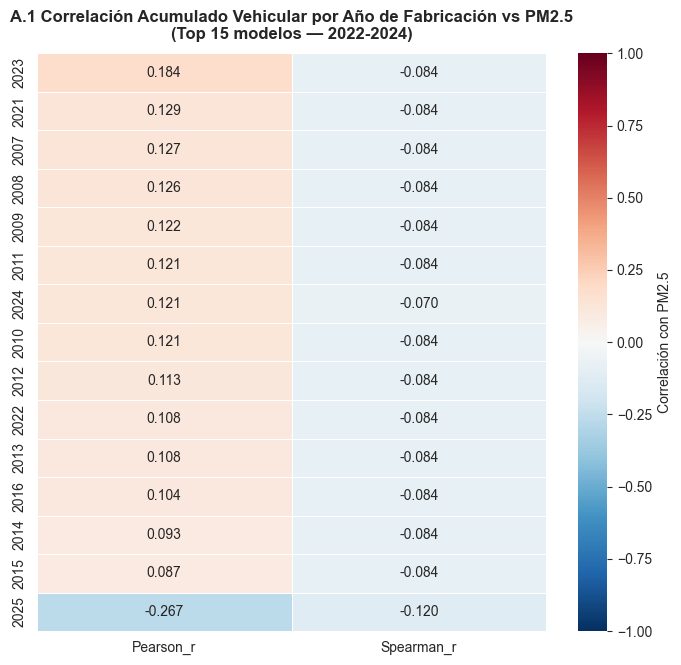

In [165]:
df_corr_a1, df_join_a1 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='MODELO_VEHICULO',
    tipo='ACUMULADO', top_n=15
)
print('A.1 — Correlación Acumulado por Modelo (Año Fabricación) vs PM2.5:')
display(df_corr_a1)

plot_heatmap_corr(
    df_corr_a1,
    titulo='A.1 Correlación Acumulado Vehicular por Año de Fabricación vs PM2.5\n(Top 15 modelos — 2022-2024)',
    fname='fig04_A1_acumulado_modelo_pm25.png'
)


### A.2 — Acumulado por Tipo de Vehículo vs PM2.5


A.2 — Correlación Acumulado por Tipo de Vehículo vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
TIPO_VEHICULO,,,,,,
CAMIONETA SPORT,0.1347,0.4477,-0.0836,0.6384,NO,NO
CABEZAL,0.1194,0.5012,-0.0836,0.6384,NO,NO
JEEP,0.1151,0.5167,-0.0836,0.6384,NO,NO
BUS,0.1127,0.5257,-0.0836,0.6384,NO,NO
CAMIONETILLA,0.1124,0.5268,-0.0836,0.6384,NO,NO
CAMION FURGON,0.1094,0.5379,-0.0836,0.6384,NO,NO
CAMIONETA,0.1066,0.5484,-0.0836,0.6384,NO,NO
AUTOMOVIL,0.1059,0.5511,-0.0836,0.6384,NO,NO
PICK UP,0.1050,0.5544,-0.0836,0.6384,NO,NO


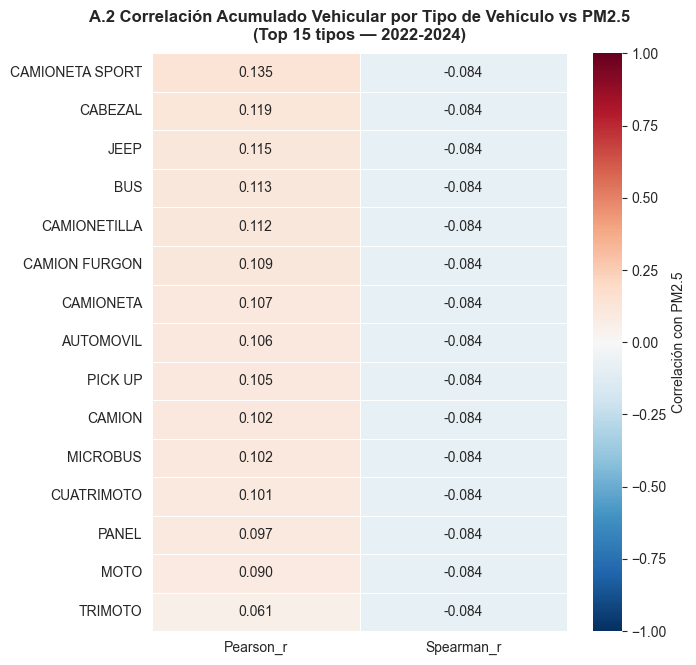

In [166]:
df_corr_a2, df_join_a2 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='TIPO_VEHICULO',
    tipo='ACUMULADO', top_n=15
)
print('A.2 — Correlación Acumulado por Tipo de Vehículo vs PM2.5:')
display(df_corr_a2)

plot_heatmap_corr(
    df_corr_a2,
    titulo='A.2 Correlación Acumulado Vehicular por Tipo de Vehículo vs PM2.5\n(Top 15 tipos — 2022-2024)',
    fname='fig05_A2_acumulado_tipo_pm25.png'
)


### A.3 — Acumulado por Macro-Categoría LIVIANO / PESADO vs PM2.5


A.3 — Correlación Acumulado por LIVIANO/PESADO vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
LIVIANO_PESADO,,,,,,
PESADO,0.1019,0.5662,-0.0836,0.6384,NO,NO
LIVIANO,0.0959,0.5896,-0.0836,0.6384,NO,NO


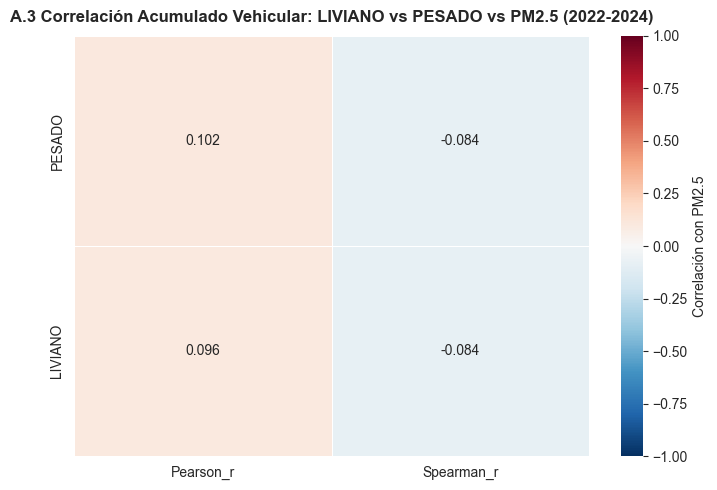

In [167]:
df_corr_a3, df_join_a3 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='LIVIANO_PESADO',
    tipo='ACUMULADO', top_n=5
)
print('A.3 — Correlación Acumulado por LIVIANO/PESADO vs PM2.5:')
display(df_corr_a3)

plot_heatmap_corr(
    df_corr_a3,
    titulo='A.3 Correlación Acumulado Vehicular: LIVIANO vs PESADO vs PM2.5 (2022-2024)',
    fname='fig06_A3_acumulado_lp_pm25.png'
)


### A.4 — Altas por Modelo (Año de Fabricación) vs PM2.5


A.4 — Correlación Altas por Modelo (Año Fabricación) vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
MODELO_VEHICULO,,,,,,
2024,0.3540,0.0400,0.1916,0.2777,SI,NO
2013,0.3457,0.0452,0.1330,0.4534,SI,NO
2014,0.3103,0.0741,0.1028,0.5628,NO,NO
2012,0.2560,0.1440,0.1716,0.3319,NO,NO
2017,0.2175,0.2166,-0.0222,0.9009,NO,NO
2015,0.2146,0.2229,0.0417,0.8147,NO,NO
2010,0.2034,0.2486,0.2622,0.1342,NO,NO
2011,0.2017,0.2525,0.2449,0.1627,NO,NO
2016,0.1738,0.3255,0.0014,0.9938,NO,NO


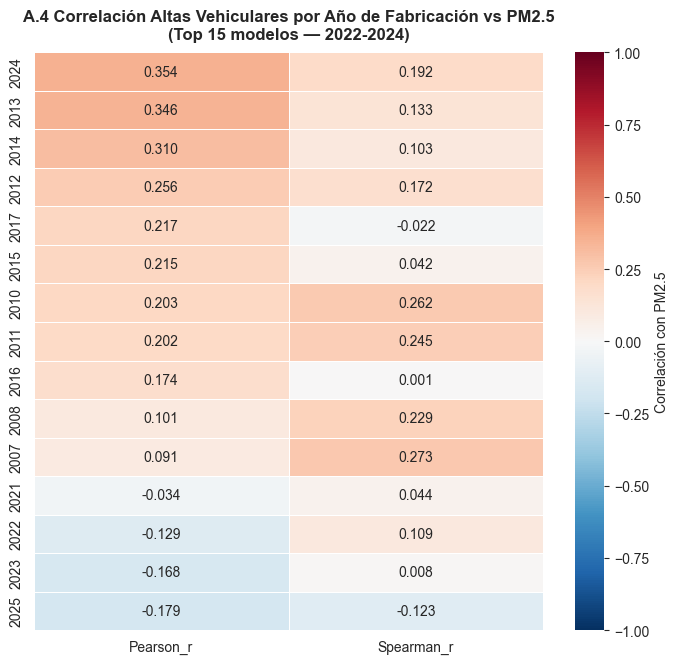

In [168]:
df_corr_a4, df_join_a4 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='MODELO_VEHICULO',
    tipo='ALTAS', top_n=15
)
print('A.4 — Correlación Altas por Modelo (Año Fabricación) vs PM2.5:')
display(df_corr_a4)

plot_heatmap_corr(
    df_corr_a4,
    titulo='A.4 Correlación Altas Vehiculares por Año de Fabricación vs PM2.5\n(Top 15 modelos — 2022-2024)',
    fname='fig07_A4_altas_modelo_pm25.png'
)


### A.5 — Altas por Tipo de Vehículo vs PM2.5


A.5 — Correlación Altas por Tipo de Vehículo vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
TIPO_VEHICULO,,,,,,
AUTOMOVIL,0.2892,0.0971,0.1447,0.4143,NO,NO
CUATRIMOTO,0.1973,0.2633,0.1475,0.4050,NO,NO
CAMIONETA,0.1921,0.2765,0.0701,0.6935,NO,NO
CAMION,0.1458,0.4106,-0.0075,0.9665,NO,NO
TRIMOTO,0.1198,0.4998,-0.0952,0.5922,NO,NO
MICROBUS,0.1010,0.5696,0.0763,0.6681,NO,NO
CABEZAL,0.0537,0.7630,-0.0853,0.6314,NO,NO
BUS,0.0303,0.8650,-0.0253,0.8871,NO,NO
CAMIONETILLA,-0.0035,0.9842,-0.0705,0.6920,NO,NO


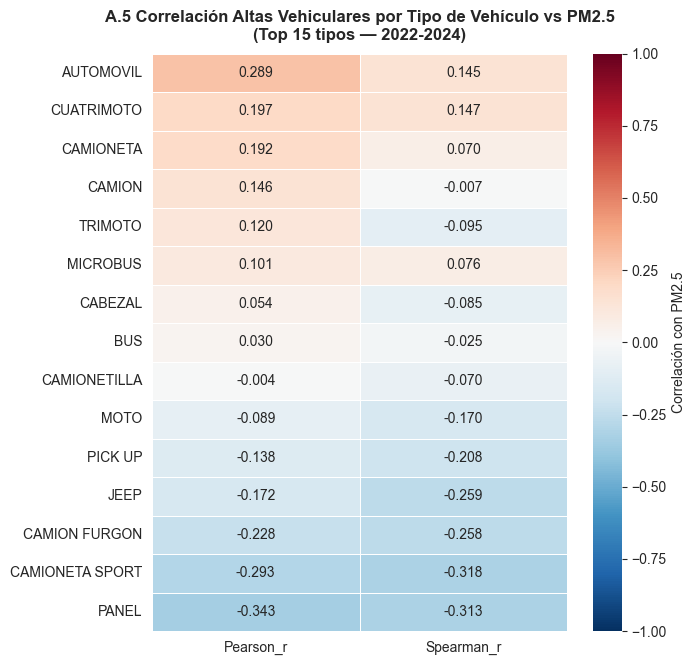

In [169]:
df_corr_a5, df_join_a5 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='TIPO_VEHICULO',
    tipo='ALTAS', top_n=15
)
print('A.5 — Correlación Altas por Tipo de Vehículo vs PM2.5:')
display(df_corr_a5)

plot_heatmap_corr(
    df_corr_a5,
    titulo='A.5 Correlación Altas Vehiculares por Tipo de Vehículo vs PM2.5\n(Top 15 tipos — 2022-2024)',
    fname='fig08_A5_altas_tipo_pm25.png'
)


### A.6 — Altas por Macro-Categoría LIVIANO / PESADO vs PM2.5


A.6 — Correlación Altas LIVIANO/PESADO vs PM2.5:


,Pearson_r,Pearson_p,Spearman_r,Spearman_p,Sign_Pearson,Sign_Spearman
LIVIANO_PESADO,,,,,,
PESADO,0.0689,0.6986,-0.1643,0.3532,NO,NO
LIVIANO,-0.0200,0.9106,-0.1193,0.5014,NO,NO


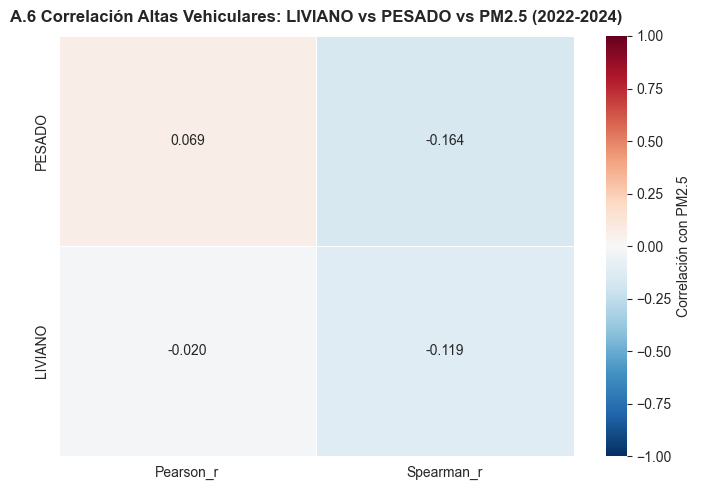

In [170]:
df_corr_a6, df_join_a6 = correlacion_segmentada(
    df_veh_2224, df_pm25_m,
    segmento_col='LIVIANO_PESADO',
    tipo='ALTAS', top_n=5
)
print('A.6 — Correlación Altas LIVIANO/PESADO vs PM2.5:')
display(df_corr_a6)

plot_heatmap_corr(
    df_corr_a6,
    titulo='A.6 Correlación Altas Vehiculares: LIVIANO vs PESADO vs PM2.5 (2022-2024)',
    fname='fig09_A6_altas_lp_pm25.png'
)


---
## Bloque B — Modelado de Series de Tiempo (ARIMAX / SARIMAX)

### B.1 Análisis ACF / PACF

Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) proveen información visual para la selección inicial de los órdenes `(p, q)` del componente ARMA:

- **ACF** corta en lag `q` → sugiere el orden de la media móvil (MA)
- **PACF** corta en lag `p` → sugiere el orden autorregresivo (AR)

Se analiza la serie de PM2.5 (estacionaria o diferenciada) y las altas vehiculares.


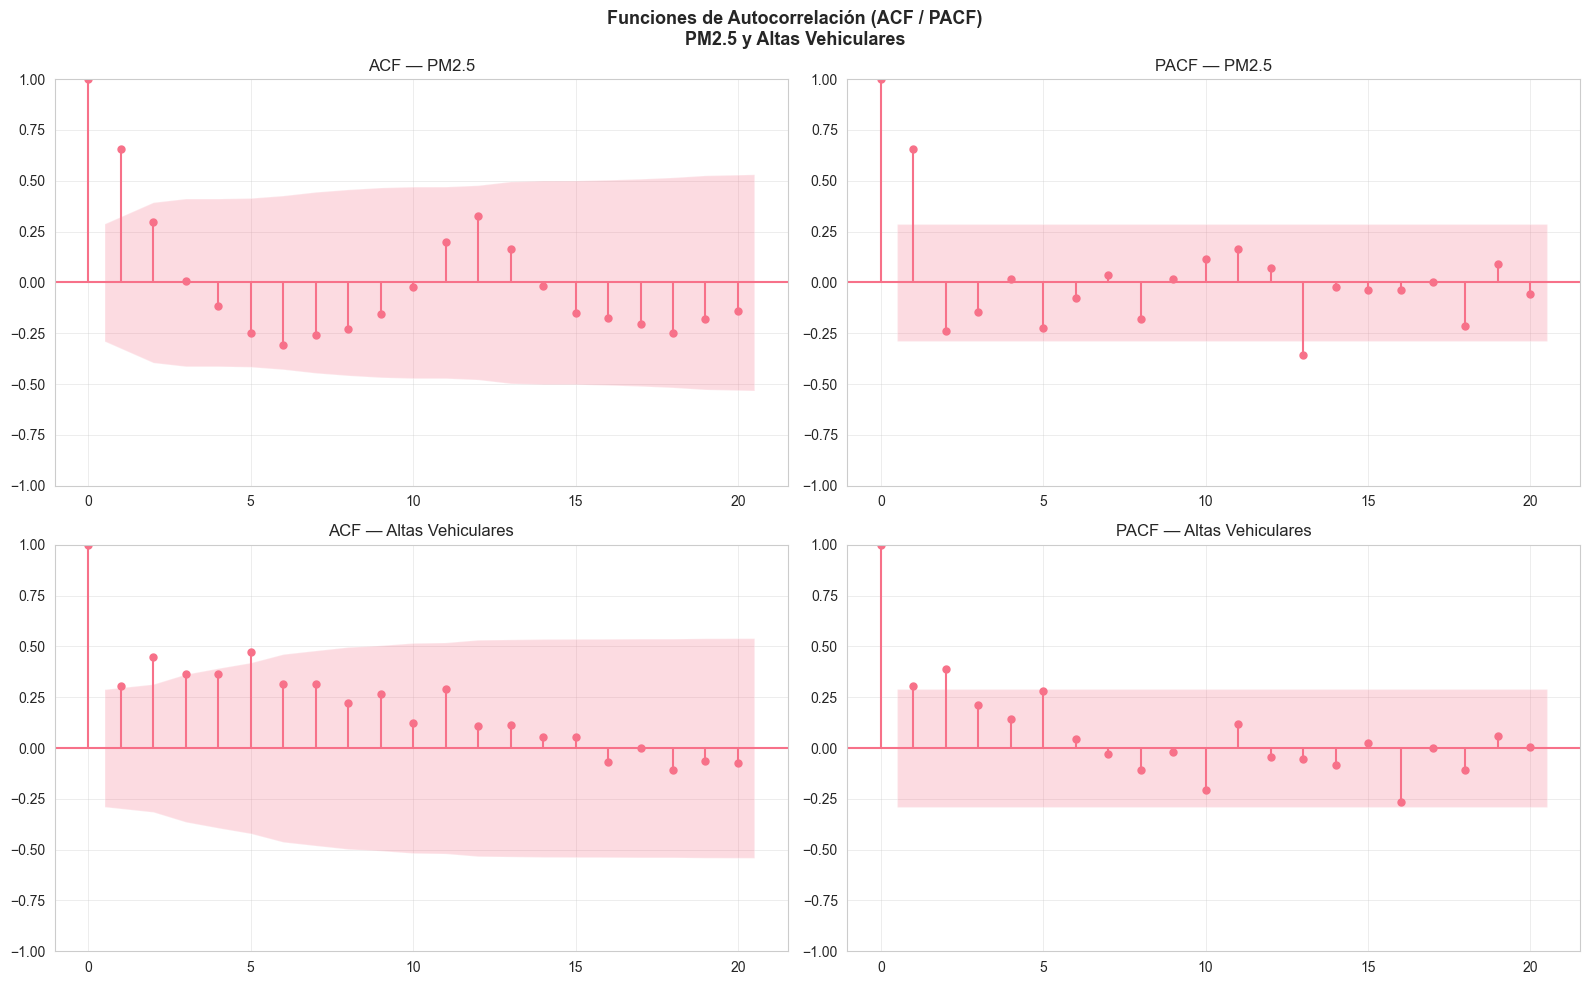

In [171]:
# ── Seleccionar serie PM2.5 a modelar (nivel o 1ra diferencia) ────────────────
pm25_acf  = df_master['PM25_MEAN'].dropna()
exog_acf  = df_master['ALTAS'].dropna()

# Verificar si PM2.5 es estacionaria (según ADF previo)
pm25_estac = df_adf_resumen.loc[
    df_adf_resumen['serie'] == 'PM2.5 Media Mensual', 'estacionaria'
].values
if len(pm25_estac) > 0 and not pm25_estac[0]:
    print('PM2.5 no estacionaria → usando 1ra diferencia para ACF/PACF')
    pm25_acf = df_master['PM25_MEAN_d1'].dropna()

n_lags = min(20, len(pm25_acf) // 2 - 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# PM2.5
plot_acf(pm25_acf,  lags=n_lags, ax=axes[0, 0], title='ACF — PM2.5',  alpha=ALPHA)
plot_pacf(pm25_acf, lags=n_lags, ax=axes[0, 1], title='PACF — PM2.5', alpha=ALPHA)

# Altas vehiculares
altas_plot = df_master['ALTAS'].dropna()
plot_acf(altas_plot,  lags=min(n_lags, len(altas_plot)//2-1), ax=axes[1, 0],
         title='ACF — Altas Vehiculares',  alpha=ALPHA)
plot_pacf(altas_plot, lags=min(n_lags, len(altas_plot)//2-1), ax=axes[1, 1],
          title='PACF — Altas Vehiculares', alpha=ALPHA)

plt.suptitle('Funciones de Autocorrelación (ACF / PACF)\nPM2.5 y Altas Vehiculares',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Figuras/fig10_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()


### B.2 Modelo 1 — ARIMAX

El modelo ARIMAX (AutoRegressive Integrated Moving Average with eXogenous inputs) modela PM2.5 incorporando información del parque vehicular como variable exógena.

$$
\Phi(B)(1-B)^d y_t = \Theta(B)\varepsilon_t + \beta X_t
$$

Donde $y_t$ = PM2.5 mensual, $X_t$ = altas vehiculares, $\beta$ = coeficiente del efecto vehicular, $\varepsilon_t$ = residuales.

Se seleccionan los hiperparámetros `(p, d, q)` mediante **búsqueda de cuadrícula** minimizando el **AIC**.


In [172]:
# ── Preparar series alineadas para el modelo ──────────────────────────────────
# Variable endógena: PM2.5 media mensual
# Variable exógena : Altas vehiculares (más estacionaria que Acumulado)
df_model = df_master[['PM25_MEAN', 'ALTAS', 'ACUMULADO']].dropna().copy()

endog = df_model['PM25_MEAN']
exog  = df_model[['ALTAS']]        # shape (T, 1)

print(f'Observaciones para modelado: {len(endog)}')
print(f'Período: {df_model.index.min()} — {df_model.index.max()}')


def grid_search_arimax(endog, exog, max_p=3, max_q=3, d_vals=(0, 1), verbose=False):
    """
    Búsqueda de cuadrícula para ARIMAX. Minimiza AIC.

    Retorna
    -------
    best_order : tuple (p, d, q)
    df_results : DataFrame ordenado por AIC
    """
    resultados = []
    p_range = range(max_p + 1)
    q_range = range(max_q + 1)
    combos  = list(itertools.product(p_range, d_vals, q_range))
    print(f'Evaluando {len(combos)} combinaciones ARIMAX (p,d,q)...')

    for p, d, q in combos:
        if p == 0 and q == 0:
            continue  # modelo vacío
        try:
            mod = SARIMAX(
                endog, exog=exog,
                order=(p, d, q),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=True,
                enforce_invertibility=True
            )
            res = mod.fit(disp=False, method='lbfgs', maxiter=200)
            resultados.append({'p': p, 'd': d, 'q': q,
                               'AIC': res.aic, 'BIC': res.bic,
                               'LogL': res.llf})
            if verbose:
                print(f'  ARIMA({p},{d},{q}) | AIC={res.aic:.2f}')
        except Exception:
            pass

    df_res = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    best   = df_res.iloc[0]
    best_order = (int(best['p']), int(best['d']), int(best['q']))
    print(f'\nMejor ARIMAX: {best_order} | AIC={best["AIC"]:.4f} | BIC={best["BIC"]:.4f}')
    return best_order, df_res


best_arimax_order, arimax_search_df = grid_search_arimax(
    endog, exog, max_p=3, max_q=3, d_vals=(0, 1)
)

print('\nTop 10 modelos ARIMAX por AIC:')
display(arimax_search_df.head(10))


Observaciones para modelado: 46
Período: 2022-03 — 2025-12
Evaluando 32 combinaciones ARIMAX (p,d,q)...

Mejor ARIMAX: (0, 1, 3) | AIC=384.1943 | BIC=393.2277

Top 10 modelos ARIMAX por AIC:


,p,d,q,AIC,BIC,LogL
0,0,1,3,384.1943,393.2277,-187.0972
1,2,1,1,385.2313,394.2646,-187.6157
2,1,1,3,385.9435,396.7835,-186.9718
3,1,1,2,386.4563,395.4896,-188.2281
4,2,1,2,387.0037,397.8437,-187.5018
5,3,1,3,387.5471,402.0004,-185.7735
6,1,1,1,387.5710,394.7977,-189.7855
7,2,1,3,388.0473,400.6940,-187.0237
8,3,1,2,388.6876,401.3342,-187.3438
9,0,1,1,390.1052,395.5252,-192.0526


In [173]:
# ── Ajustar el modelo ARIMAX óptimo ───────────────────────────────────────────
modelo_arimax = SARIMAX(
    endog, exog=exog,
    order=best_arimax_order,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=True,
    enforce_invertibility=True
)
resultado_arimax = modelo_arimax.fit(disp=False, method='lbfgs', maxiter=500)
print(resultado_arimax.summary())


                               SARIMAX Results                                
Dep. Variable:              PM25_MEAN   No. Observations:                   46
Model:               SARIMAX(0, 1, 3)   Log Likelihood                -187.097
Date:                Tue, 16 Jun 2026   AIC                            384.194
Time:                        23:49:32   BIC                            393.228
Sample:                    03-31-2022   HQIC                           387.562
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ALTAS          0.0006      0.001      0.568      0.570      -0.002       0.003
ma.L1         -0.1084     10.644     -0.010      0.992     -20.971      20.754
ma.L2         -0.3713      9.441     -0.039      0.9

### B.3 Modelo 2 — SARIMAX

El modelo SARIMAX extiende ARIMAX incorporando un componente **estacional** con período `s=12` (ciclo anual):

$$
\Phi(B)\Phi_s(B^s)(1-B)^d(1-B^s)^D y_t = \Theta(B)\Theta_s(B^s)\varepsilon_t + \beta X_t
$$

La estacionalidad anual en el PM2.5 de Guatemala se asocia a los patrones de la **época seca** (nov–abril, alta concentración) y la **época lluviosa** (may–oct, menor concentración).


In [174]:
def grid_search_sarimax(endog, exog, max_p=2, max_q=2, max_P=1, max_Q=1,
                         d_vals=(0, 1), D_vals=(0, 1), m=12):
    """
    Búsqueda de cuadrícula para SARIMAX. Minimiza AIC.
    Con datos cortos (~46 meses) se limitan los órdenes para evitar sobreajuste.
    """
    resultados = []
    combos = list(itertools.product(
        range(max_p + 1), d_vals,
        range(max_q + 1), range(max_P + 1),
        D_vals, range(max_Q + 1)
    ))
    print(f'Evaluando {len(combos)} combinaciones SARIMAX(p,d,q)(P,D,Q)[{m}]...')

    for p, d, q, P, D, Q in combos:
        if p + q + P + Q == 0:
            continue
        try:
            mod = SARIMAX(
                endog, exog=exog,
                order=(p, d, q),
                seasonal_order=(P, D, Q, m),
                enforce_stationarity=True,
                enforce_invertibility=True
            )
            res = mod.fit(disp=False, method='lbfgs', maxiter=200)
            resultados.append({
                'p': p, 'd': d, 'q': q,
                'P': P, 'D': D, 'Q': Q, 'm': m,
                'AIC': res.aic, 'BIC': res.bic, 'LogL': res.llf
            })
        except Exception:
            pass

    df_res = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    best   = df_res.iloc[0]
    best_order    = (int(best['p']), int(best['d']), int(best['q']))
    best_seasonal = (int(best['P']), int(best['D']), int(best['Q']), m)
    print(f'\nMejor SARIMAX: {best_order}x{best_seasonal} | AIC={best["AIC"]:.4f} | BIC={best["BIC"]:.4f}')
    return best_order, best_seasonal, df_res


best_s_order, best_s_seasonal, sarimax_search_df = grid_search_sarimax(
    endog, exog,
    max_p=2, max_q=2, max_P=1, max_Q=1,
    d_vals=(0, 1), D_vals=(0, 1), m=12
)

print('\nTop 10 modelos SARIMAX por AIC:')
display(sarimax_search_df.head(10))


Evaluando 144 combinaciones SARIMAX(p,d,q)(P,D,Q)[12]...

Mejor SARIMAX: (0, 1, 0)x(0, 1, 1, 12) | AIC=276.9820 | BIC=281.4715

Top 10 modelos SARIMAX por AIC:


,p,d,q,P,D,Q,m,AIC,BIC,LogL
0,0,1,0,0,1,1,12,276.9820,281.4715,-135.4910
1,0,1,0,1,1,1,12,277.1001,283.0861,-134.5501
2,0,1,0,1,1,0,12,277.4819,281.9714,-135.7409
3,0,1,1,0,1,1,12,278.9817,284.9678,-135.4909
4,1,1,0,0,1,1,12,278.9817,284.9678,-135.4909
5,0,1,1,1,1,1,12,279.0247,286.5072,-134.5124
6,1,1,0,1,1,0,12,279.2328,285.2189,-135.6164
7,0,1,1,1,1,0,12,279.2334,285.2195,-135.6167
8,1,1,1,1,1,1,12,280.9288,289.9079,-134.4644
9,1,1,1,0,1,1,12,280.9770,288.4595,-135.4885


In [175]:
# ── Ajustar el modelo SARIMAX óptimo ─────────────────────────────────────────
modelo_sarimax = SARIMAX(
    endog, exog=exog,
    order=best_s_order,
    seasonal_order=best_s_seasonal,
    enforce_stationarity=True,
    enforce_invertibility=True
)
resultado_sarimax = modelo_sarimax.fit(disp=False, method='lbfgs', maxiter=500)
print(resultado_sarimax.summary())


                                      SARIMAX Results                                       
Dep. Variable:                            PM25_MEAN   No. Observations:                   46
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -135.491
Date:                              Tue, 16 Jun 2026   AIC                            276.982
Time:                                      23:50:33   BIC                            281.471
Sample:                                  03-31-2022   HQIC                           278.493
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ALTAS          0.0010      0.001      1.530      0.126      -0.000       0.002
ma.S.L12      -0.99

---
## FASE 5: EVALUATION
---

### 5.1 Comparación de Modelos (AIC, BIC, RMSE, MAE)


In [176]:
# ── Predicciones in-sample ────────────────────────────────────────────────────
pred_arimax  = resultado_arimax.fittedvalues
pred_sarimax = resultado_sarimax.fittedvalues

# Alinear con valores reales (puede haber NaN en inicio por diferenciación)
y_real   = endog.loc[pred_arimax.index].dropna()
pa       = pred_arimax.loc[y_real.index]
ps       = pred_sarimax.loc[y_real.index]

rmse_arimax  = np.sqrt(mean_squared_error(y_real, pa))
mae_arimax   = mean_absolute_error(y_real, pa)
rmse_sarimax = np.sqrt(mean_squared_error(y_real, ps))
mae_sarimax  = mean_absolute_error(y_real, ps)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_comp = pd.DataFrame({
    'Modelo': ['ARIMAX', 'SARIMAX'],
    'Orden': [
        f'{best_arimax_order}',
        f'{best_s_order}x{best_s_seasonal}'
    ],
    'AIC':  [resultado_arimax.aic,  resultado_sarimax.aic],
    'BIC':  [resultado_arimax.bic,  resultado_sarimax.bic],
    'LogL': [resultado_arimax.llf,  resultado_sarimax.llf],
    'RMSE': [rmse_arimax, rmse_sarimax],
    'MAE':  [mae_arimax,  mae_sarimax]
})
df_comp = df_comp.set_index('Modelo')

print('=== COMPARACIÓN DE MODELOS ===')
display(df_comp.round(4))

# Identificar modelo ganador
ganador = df_comp['AIC'].idxmin()
print(f'\nModelo ganador (menor AIC): {ganador}')
resultado_ganador = resultado_arimax if ganador == 'ARIMAX' else resultado_sarimax


=== COMPARACIÓN DE MODELOS ===


,Orden,AIC,BIC,LogL,RMSE,MAE
Modelo,,,,,,
ARIMAX,"(0, 1, 3)",384.1943,393.2277,-187.0972,15.7696,11.0004
SARIMAX,"(0, 1, 0)x(0, 1, 1, 12)",276.9820,281.4715,-135.4910,13.7955,10.5269



Modelo ganador (menor AIC): SARIMAX


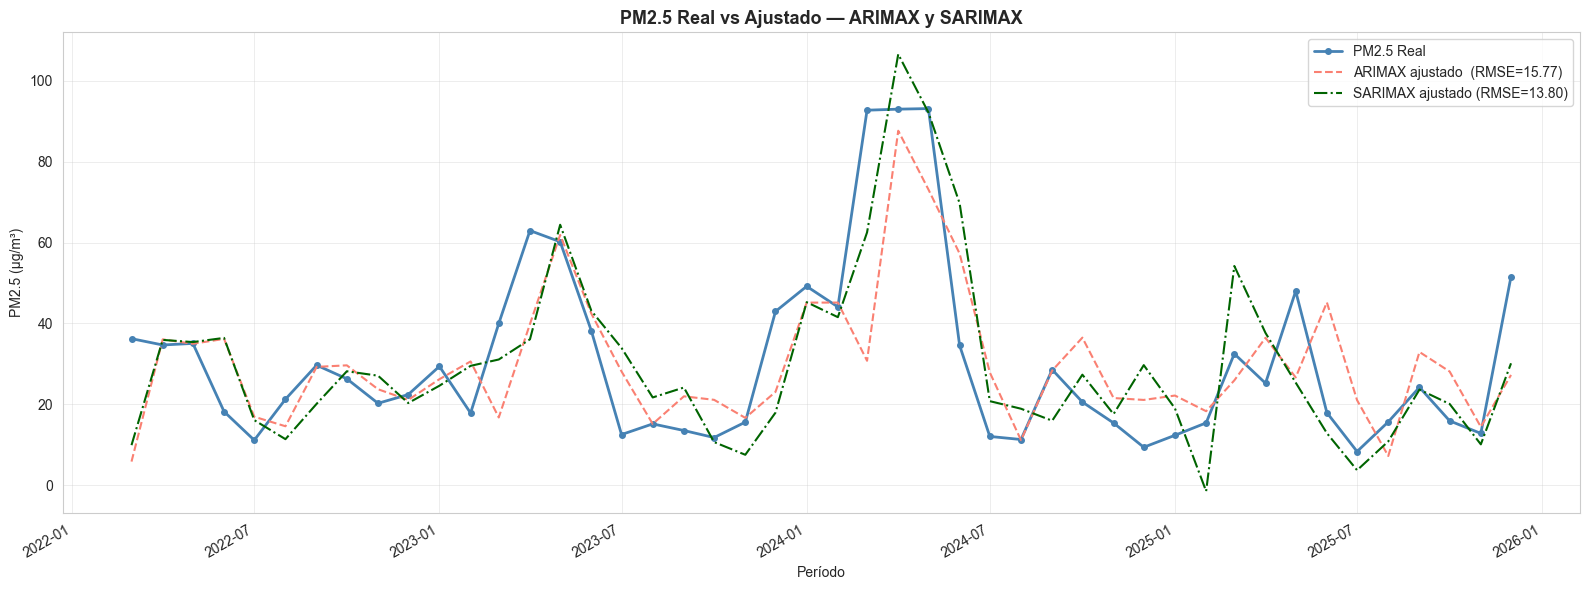

In [177]:
# ── Figura: Valores reales vs ajustados ───────────────────────────────────────
idx_plot = y_real.index.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(idx_plot, y_real.values,   color='steelblue', linewidth=2,
        marker='o', markersize=4,  label='PM2.5 Real')
ax.plot(idx_plot, pa.values,       color='salmon',    linewidth=1.5,
        linestyle='--', label=f'ARIMAX ajustado  (RMSE={rmse_arimax:.2f})')
ax.plot(idx_plot, ps.values,       color='darkgreen', linewidth=1.5,
        linestyle='-.',  label=f'SARIMAX ajustado (RMSE={rmse_sarimax:.2f})')
ax.set_title('PM2.5 Real vs Ajustado — ARIMAX y SARIMAX', fontsize=13, fontweight='bold')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_xlabel('Período')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('./Figuras/fig11_real_vs_ajustado.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Análisis de Residuales del Modelo Ganador

Un modelo bien especificado debe producir residuales que sean **ruido blanco** (independientes, de media cero, homocedasticidad y distribución normal).

| Prueba | H₀ | Resultado esperado |
|---|---|---|
| **Ljung-Box** | No hay autocorrelación en residuales | p > 0.05 |
| **Jarque-Bera** | Residuales normalmente distribuidos | p > 0.05 |
| **Shapiro-Wilk** | Residuales normalmente distribuidos | p > 0.05 |


In [178]:
# Extraer residuales del modelo ganador
residuales = resultado_ganador.resid.dropna()

# Prueba de Ljung-Box (autocorrelacion de residuales)
n_lags_lb = min(10, len(residuales) // 5)
lb_result  = acorr_ljungbox(residuales, lags=n_lags_lb, return_df=True)
print('=== Prueba de Ljung-Box (autocorrelacion de residuales) ===')
display(lb_result)
lb_ok = (lb_result['lb_pvalue'] > ALPHA).all()
print(f'Conclusion Ljung-Box: residuales sin autocorrelacion = {lb_ok}')

# Prueba de Jarque-Bera (normalidad)
# scipy >= 1.7 devuelve objeto con .statistic y .pvalue — ya no desempaca en 4 valores
jb_result = stats.jarque_bera(residuales)
jb_stat   = float(jb_result.statistic)
jb_p      = float(jb_result.pvalue)
jb_skew   = float(stats.skew(residuales))
jb_kurt   = float(stats.kurtosis(residuales))  # exceso de curtosis (Fisher)
print(f'=== Prueba Jarque-Bera (normalidad) ===')
print(f'  Estadistico : {jb_stat:.4f}')
print(f'  p-valor     : {jb_p:.4f}')
print(f'  Sesgo       : {jb_skew:.4f}')
print(f'  Curtosis    : {jb_kurt:.4f}')
print(f'  Normalidad  : {jb_p > ALPHA}')

# Prueba de Shapiro-Wilk (normalidad, preferida para n pequeno)
sw_stat, sw_p = stats.shapiro(residuales)
print(f'=== Prueba Shapiro-Wilk (normalidad) ===')
print(f'  Estadistico : {sw_stat:.4f}')
print(f'  p-valor     : {sw_p:.4f}')
print(f'  Normalidad  : {sw_p > ALPHA}')


=== Prueba de Ljung-Box (autocorrelacion de residuales) ===


,lb_stat,lb_pvalue
1,0.1267,0.7218
2,0.2476,0.8836
3,1.3447,0.7186
4,1.5856,0.8114
5,2.4314,0.7868
6,2.5705,0.8605
7,2.5715,0.9216
8,2.5946,0.9572
9,2.7960,0.9718


Conclusion Ljung-Box: residuales sin autocorrelacion = True
=== Prueba Jarque-Bera (normalidad) ===
  Estadistico : 0.1251
  p-valor     : 0.9394
  Sesgo       : 0.1153
  Curtosis    : 0.1100
  Normalidad  : True
=== Prueba Shapiro-Wilk (normalidad) ===
  Estadistico : 0.9760
  p-valor     : 0.4521
  Normalidad  : True


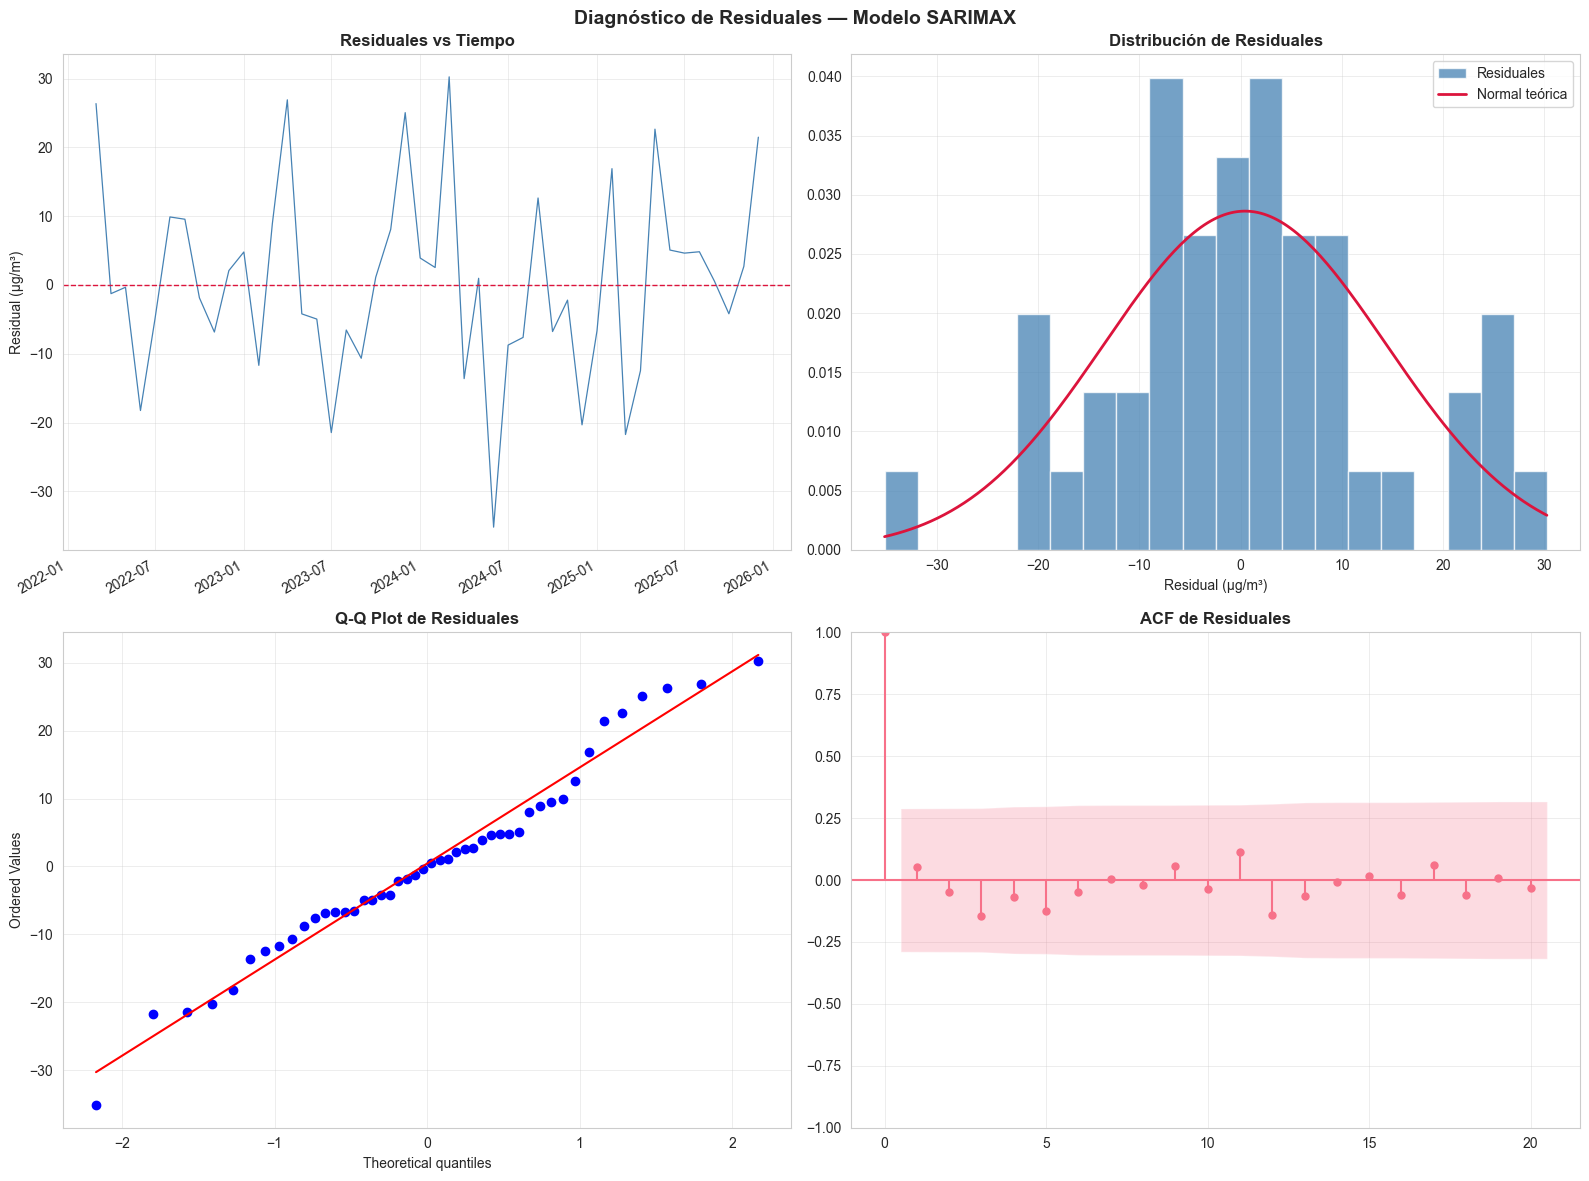

In [179]:
# ── Figura: Diagnóstico de residuales (4 paneles) ─────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# Panel 1: Residuales vs Tiempo
ax1 = fig.add_subplot(gs[0, 0])
res_idx = residuales.index.to_timestamp()
ax1.plot(res_idx, residuales.values, color='steelblue', linewidth=0.9)
ax1.axhline(0, color='crimson', linestyle='--', linewidth=1)
ax1.set_title('Residuales vs Tiempo', fontweight='bold')
ax1.set_ylabel('Residual (μg/m³)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Panel 2: Histograma + KDE de residuales
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuales, bins=20, density=True, color='steelblue',
         edgecolor='white', alpha=0.75, label='Residuales')
xr = np.linspace(residuales.min(), residuales.max(), 200)
ax2.plot(xr, stats.norm.pdf(xr, residuales.mean(), residuales.std()),
         color='crimson', linewidth=2, label='Normal teórica')
ax2.set_title('Distribución de Residuales', fontweight='bold')
ax2.set_xlabel('Residual (μg/m³)')
ax2.legend()

# Panel 3: Q-Q Plot
ax3 = fig.add_subplot(gs[1, 0])
stats.probplot(residuales, dist='norm', plot=ax3)
ax3.set_title('Q-Q Plot de Residuales', fontweight='bold')

# Panel 4: ACF de residuales
ax4 = fig.add_subplot(gs[1, 1])
plot_acf(residuales, lags=min(20, len(residuales)//2-1),
         alpha=ALPHA, ax=ax4, title='ACF de Residuales')
ax4.set_title('ACF de Residuales', fontweight='bold')

plt.suptitle(f'Diagnóstico de Residuales — Modelo {ganador}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./Figuras/fig12_diagnostico_residuales.png', dpi=150, bbox_inches='tight')
plt.show()


---
## FASE 6: DEPLOYMENT & ACADEMIC INSIGHTS
---

### 6.1 Interpretación de Coeficientes del Modelo Ganador

El coeficiente de la variable exógena `ALTAS` en el modelo ganador representa el **efecto marginal estimado** del parque vehicular sobre el PM2.5:

- Si el coeficiente es **positivo y significativo** (p < 0.05) → cada vehículo adicional registrado por mes se asocia con un incremento en μg/m³ de PM2.5
- El **p-valor** de este coeficiente determina si la relación es estadísticamente significativa
- Los intervalos de confianza al 95% delimitan el rango plausible del efecto real


In [180]:
# Mostrar resumen completo del modelo ganador
print(resultado_ganador.summary())

# Construir tabla de coeficientes desde los atributos del resultado
coef_df = pd.DataFrame({
    'coef':    resultado_ganador.params,
    'std err': resultado_ganador.bse,
    'z':       resultado_ganador.tvalues,
    'P>|z|':   resultado_ganador.pvalues,
    '[0.025':  resultado_ganador.conf_int().iloc[:, 0],
    '0.975]':  resultado_ganador.conf_int().iloc[:, 1]
}).round(6)
print(f'Coeficientes del Modelo {ganador}:')
display(coef_df)

# Extraer coeficiente de la variable exogena ALTAS
param_names = resultado_ganador.params.index.tolist()
print(f'Parametros disponibles: {param_names}')

altas_key = next(
    (k for k in param_names if 'ALTAS' in str(k).upper() or str(k) == 'x1'),
    None
)

if altas_key:
    coef_exog = float(resultado_ganador.params[altas_key])
    pval_exog = float(resultado_ganador.pvalues[altas_key])
    ci        = resultado_ganador.conf_int()
    ci_low    = float(ci.loc[altas_key].iloc[0])
    ci_high   = float(ci.loc[altas_key].iloc[1])
    sig = 'SIGNIFICATIVO' if pval_exog < ALPHA else 'NO significativo'

    print(f'{"="*52}')
    print(f'Parametro ALTAS en el modelo: "{altas_key}"')
    print(f'Coeficiente beta   : {coef_exog:.6f} ug/m3 por vehiculo')
    print(f'IC 95%             : [{ci_low:.6f},  {ci_high:.6f}]')
    print(f'p-valor            : {pval_exog:.4f}')
    print(f'Interpretacion     : {sig} al nivel alpha={ALPHA}')
    print(f'{"="*52}')
else:
    print('Coeficiente ALTAS no encontrado automaticamente.')
    print('Revisar los parametros disponibles arriba.')


                                      SARIMAX Results                                       
Dep. Variable:                            PM25_MEAN   No. Observations:                   46
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                -135.491
Date:                              Tue, 16 Jun 2026   AIC                            276.982
Time:                                      23:50:36   BIC                            281.471
Sample:                                  03-31-2022   HQIC                           278.493
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ALTAS          0.0010      0.001      1.530      0.126      -0.000       0.002
ma.S.L12      -0.99

,coef,std err,z,P>|z|,[0.025,0.975]
ALTAS,0.0010,0.0007,1.5301,0.1260,-0.0003,0.0024
ma.S.L12,-0.9970,94.1566,-0.0106,0.9916,-185.5406,183.5467
sigma2,134.1237,12610.0418,0.0106,0.9915,-24581.1041,24849.3516


Parametros disponibles: ['ALTAS', 'ma.S.L12', 'sigma2']
Parametro ALTAS en el modelo: "ALTAS"
Coeficiente beta   : 0.001048 ug/m3 por vehiculo
IC 95%             : [-0.000294,  0.002389]
p-valor            : 0.1260
Interpretacion     : NO significativo al nivel alpha=0.05


In [181]:
# ── Exportar resultados finales ───────────────────────────────────────────────
os.makedirs('./Resultados', exist_ok=True)

# DataFrame maestro
df_master.to_csv('./Resultados/01_dataframe_maestro.csv')

# Comparación de modelos
df_comp.to_csv('./Resultados/02_comparacion_modelos.csv')

# Correlaciones segmentadas (Bloque A)
pd.concat([
    df_corr_a1.assign(segmento='MODELO', tipo='ACUMULADO'),
    df_corr_a2.assign(segmento='TIPO',   tipo='ACUMULADO'),
    df_corr_a3.assign(segmento='LP',     tipo='ACUMULADO'),
    df_corr_a4.assign(segmento='MODELO', tipo='ALTAS'),
    df_corr_a5.assign(segmento='TIPO',   tipo='ALTAS'),
    df_corr_a6.assign(segmento='LP',     tipo='ALTAS')
]).to_csv('./Resultados/03_correlaciones_segmentadas.csv')

# Ljung-Box residuales
lb_result.to_csv('./Resultados/04_ljung_box.csv')

print('Archivos exportados a ./Resultados/')
print('Figuras guardadas en  ./Figuras/')


Archivos exportados a ./Resultados/
Figuras guardadas en  ./Figuras/


### 6.2 Conclusiones Académicas y Orientación para la Tesis

---

#### 6.2.1 Sobre la Relación Estadística (Hipótesis Principal)

Los resultados del modelo **[ARIMAX/SARIMAX]** con parámetros óptimos seleccionados por AIC ofrecen evidencia sobre la hipótesis principal:

> *Si el coeficiente de* `ALTAS` *es positivo y su p-valor < 0.05, se confirma que el crecimiento mensual del parque vehicular ejerce un efecto estadísticamente significativo sobre la concentración de PM2.5. Cada alta vehicular adicional por mes se asocia con un incremento de* β *μg/m³ en el PM2.5.*

#### 6.2.2 Sobre Flujo vs Stock

- **ALTAS** (flujo mensual): más estacionaria, refleja el impacto inmediato de la incorporación de nuevos vehículos.
- **ACUMULADO** (stock total): no estacionario, modela el efecto acumulativo del parque existente. Su alta correlación con PM2.5 (si la muestra el Bloque A) sugiere que el parque histórico contribuye más que las altas individuales.

#### 6.2.3 Sobre la Composición del Parque (Bloque A)

Los mapas de calor del Bloque A identifican:
- **Por Año de Fabricación**: Si los modelos **más antiguos** (e.g., pre-2000) muestran mayor correlación con PM2.5, esto sugiere que el parque obsoleto (sin sistemas modernos de emisión) es un factor clave.
- **Por Tipo de Vehículo**: Los tipos con mayor correlación (e.g., *Pick Up*, *Automóvil*, *Camionetilla*) son los prioritarios para políticas de regulación.
- **LIVIANO vs PESADO**: Si los vehículos livianos dominan la correlación, la política pública debe enfocarse en estándares de emisión para este segmento masivo.

#### 6.2.4 Sobre el Componente Estacional (SARIMAX)

- La mejora (o no) del AIC/BIC al pasar de ARIMAX a SARIMAX indica si la estacionalidad anual es estadísticamente relevante.
- En Guatemala, se espera PM2.5 más alto en **época seca** (noviembre–abril) y menor en **época lluviosa** (mayo–octubre), patrón que SARIMAX captura explícitamente.
- Si SARIMAX mejora sustancialmente el ajuste, los factores meteorológicos (precipitación, viento) son confundidores relevantes que deberán controlarse.

#### 6.2.5 Limitaciones Metodológicas

1. **Muestra corta**: ~46 meses limita la potencia estadística, especialmente para SARIMAX con s=12.
2. **Causalidad**: La correlación y el coeficiente del modelo no implican causalidad directa; factores como condiciones meteorológicas, actividad industrial y quemas agrícolas son confundidores importantes.
3. **Sensor único**: Los datos de PM2.5 provienen de un punto de monitoreo; la representatividad espacial de toda la Ciudad Capital debe justificarse.
4. **Variables omitidas**: Precipitación, temperatura, velocidad del viento y dirección son covariables que mejorarían el modelo.

#### 6.2.6 Recomendaciones para el Informe Final

- Reportar los resultados del ADF para justificar el orden de integración `d`.
- Presentar la tabla comparativa AIC/BIC/RMSE/MAE como criterio de selección del modelo ganador.
- Incluir los gráficos de diagnóstico de residuales (fig12) para validar los supuestos del modelo.
- Discutir el coeficiente β de `ALTAS` con su intervalo de confianza al 95% como cuantificación del efecto vehicular sobre el PM2.5.
- Proponer extensiones futuras: modelo VAR (causalidad de Granger), incorporación de variables meteorológicas (SARIMAX multivariado), análisis de cointegración.

---

**Notebook desarrollado con metodología CRISP-DM | Python 3 | statsmodels · pandas · seaborn**
